# Brussels Loneliness Regression Analysis

Analysis of isolation rates and socioeconomic indicators in Brussels statistical sectors using OLS and Geographically Weighted Regression.

In [31]:
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import shape
from concurrent.futures import ThreadPoolExecutor, as_completed
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

## 1. Fetch Data from Brussels Perspective API

In [32]:
# Define all indicator URLs
urls = [
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25137/fr',  # Isolated 30+ 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63135/fr',  # Isolated 30+ 2022 "Indicator 2379"
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25059/fr',  # Isolated 65+ 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/62796/fr',  # Isolated 65+ 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25425/fr',  # Densité 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/60623/fr',  # Densité 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/24768/fr',  # Average age 2021 
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/59737/fr',  # Average age 2022
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63403/fr',  # Median Income 2021
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/59638/fr',  # Avg distance to base good 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/62196/fr',  # Employment rate 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/64044/fr',  # Employment rate 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63497/fr',  # Vegetal rate 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/23256/fr',  # Public transport access 2018
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/20869/fr',  # Part de la voirie dédiée au trottoir 2014
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/60521/fr',  # Impermeable surfaces 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/60616/fr',  # NO2 concentration 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63308/fr',  # Office density 2020
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/23221/fr',  # Green space access 2012
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/24586/fr',  # Private garden access 2001,
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25435/fr',  # EU Population 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/61803/fr',  # EU Population 2022
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25366/fr',  # North Africa Population 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/61818/fr',  # North Africa Population 2022
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/62141/fr', # Population Growth 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/61936/fr',  # Population Growth 2022
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/24714/fr', # Share 30-44 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63124/fr', # Share 30-44 2022
    'https://geodata.perspective.brussels/api/geodata/mdq/geojson/25278/fr', # Share 65+ 2021
    #'https://geodata.perspective.brussels/api/geodata/mdq/geojson/63232/fr' # Share 65+ 2022
]

def fetch_geojson(url):
    """Fetch GeoJSON data from URL and extract metadata"""
    try:
        response = requests.get(url, timeout=15)
        if response.status_code == 200:
            filename = response.headers.get('content-disposition', '').split('filename=')[-1].strip('"\'')
            geojson = response.json()
            return {'url': url, 'filename': filename, 'data': geojson, 'status': 'valid', 'error': None}
        else:
            return {'url': url, 'filename': None, 'data': None, 'status': 'failed', 
                    'error': f'HTTP {response.status_code}'}
    except Exception as e:
        return {'url': url, 'filename': None, 'data': None, 'status': 'failed', 
                'error': str(e)}

# Fetch all URLs in parallel
print(f'Fetching {len(urls)} indicators...', end=' ')
results = []
with ThreadPoolExecutor(max_workers=10) as executor:
    results = list(executor.map(fetch_geojson, urls))
valid_results = [r for r in results if r['status'] == 'valid']
print(f'✓ ({len(valid_results)}/{len(urls)} successful)')

# Show errors if any failed
failed_results = [r for r in results if r['status'] == 'failed']
if failed_results:
    print(f'\n⚠ {len(failed_results)} URLs failed:')
    for r in failed_results[:5]:  # Show first 5 errors
        print(f'  - {r["url"]}: {r["error"]}')

Fetching 8 indicators... ✓ (8/8 successful)


## 2. Create GeoDataFrame

In [33]:
def extract_metadata(filename):
    """Extract year, area, and metric name from filename"""
    import re
    parts = filename.replace('.geojson', '').split('_')
    year = None
    for part in parts:
        if re.match(r'^\d{4}$', part):
            year = int(part)
            break
    area = parts[-1]
    metric_name = ' '.join([p for p in parts if not re.match(r'^\d{4}$', p) and p != area])
    return year, area, metric_name

# Check if we have data to process
if not valid_results:
    raise ValueError("No data was successfully fetched. Please check the URLs and your internet connection.")

# Build GeoDataFrame from all features
print('Converting to GeoDataFrame...', end=' ')
all_data = []
for result in valid_results:
    year, area, metric_name = extract_metadata(result['filename'])
    for feature in result['data']['features']:
        props = feature['properties']
        all_data.append({
            'geometry': shape(feature['geometry']),
            'id': feature.get('id'),
            'name': props.get('name'),
            'value': props.get('value'),
            'year': year,
            'metric_name': metric_name,
            'area_type': area
        })

gdf = gpd.GeoDataFrame(all_data, crs='EPSG:31370')
print(f'✓ ({len(gdf)} features, {gdf["metric_name"].nunique()} metrics)')

Converting to GeoDataFrame... ✓ (5789 features, 8 metrics)


## 3. Visualize Data

In [54]:
import os

def create_map_grid(gdf, output_file='metrics_grid.png', maps_per_row=4):
    """Create grid of metric maps"""
    metrics = sorted(gdf['metric_name'].unique())
    num_rows = (len(metrics) + maps_per_row - 1) // maps_per_row
    figsize = (12 * maps_per_row // 2, 8 * num_rows)
    fig, axes = plt.subplots(num_rows, maps_per_row, figsize=figsize)
    axes = axes.flatten() if num_rows > 1 else [axes] if maps_per_row == 1 else axes.flatten()
    
    gdf_wgs84 = gdf.to_crs('EPSG:4326')
    
    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        data = gdf_wgs84[gdf_wgs84['metric_name'] == metric]
        data_with_values = data[data['value'].notna()]
        
        if len(data_with_values) > 0:
            data.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray', linewidth=0.3)
            data_with_values.plot(ax=ax, column='value', cmap='YlOrRd', edgecolor='black', 
                                 linewidth=0.3, alpha=0.8, legend=True)
            year = data['year'].iloc[0]
            ax.set_title(f'{metric}\n({year})', fontsize=10, fontweight='bold')
        ax.axis('off')
    
    for idx in range(len(metrics), len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.savefig(output_file, dpi=150, bbox_inches='tight')
    plt.close()
    print(f'\u2713 Saved grid map to {output_file}')


def save_individual_maps(gdf, output_dir='metric_maps'):
    """Sauvegarde une carte PNG par variable dans output_dir"""
    os.makedirs(output_dir, exist_ok=True)
    metrics = sorted(gdf['metric_name'].unique())
    gdf_wgs84 = gdf.to_crs('EPSG:4326')

    for metric in metrics:
        data = gdf_wgs84[gdf_wgs84['metric_name'] == metric]
        data_with_values = data[data['value'].notna()]

        fig, ax = plt.subplots(figsize=(10, 8))

        if len(data_with_values) > 0:
            data.plot(ax=ax, alpha=0.3, edgecolor='black', color='lightgray', linewidth=0.3)
            data_with_values.plot(ax=ax, column='value', cmap='YlOrRd', edgecolor='black',
                                  linewidth=0.3, alpha=0.8, legend=True)
            year = data['year'].iloc[0]
            ax.set_title(f'{metric}\n({year})', fontsize=12, fontweight='bold')

        ax.axis('off')
        plt.tight_layout()

        filename = metric.replace('/', '_').replace(' ', '_') + '.png'
        filepath = os.path.join(output_dir, filename)
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close()
        print(f'  \u2713 {filename}')

    print(f'\n\u2713 {len(metrics)} cartes sauvegard\u00e9es dans {output_dir}/')


create_map_grid(gdf)
save_individual_maps(gdf)

✓ Saved grid map to metrics_grid.png
  ✓ distance-moyenne-dacces-aux-4-biens-de-base.png
  ✓ part-de-leurope-des-14-hors-belgique.png
  ✓ part-des-30-44-ans-dans-la-population-totale.png
  ✓ part-des-65-ans-et-plus-dans-la-population-totale.png
  ✓ part-des-isoles-de-30-ans-et-plus-dans-le-total-des-menages-prives.png
  ✓ part-des-logements-ayant-acces-a-un-jardin-prive.png
  ✓ revenu-equivalent-median-des-habitants-apres-impot.png
  ✓ taux-de-croissance-annuel-moyen-de-la-population.png

✓ 8 cartes sauvegardées dans metric_maps/


## 4. Variable Summary Statistics and Correlation Analysis

VARIABLE SUMMARY STATISTICS

Table: Descriptive Statistics for All Variables
--------------------------------------------------------------------------------
                                                          Variable   N      Moyenne  Écart-type     Min      Max  Valeurs manquantes
part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives 626    37.287508    7.294710   12.98    62.82                  75
                       distance_moyenne_dacces_aux_4_biens_de_base 700   242.841371  209.969905   45.94  3235.37                   1
                              part_de_leurope_des_14_hors_belgique 626    16.141997   10.026434    1.74    45.68                  75
                      part_des_30_44_ans_dans_la_population_totale 626    23.300767    5.565009    1.57    47.20                  75
                 part_des_65_ans_et_plus_dans_la_population_totale 626    13.975655    6.657306    0.79    75.29                  75
                  part_des_logements_ayant_a

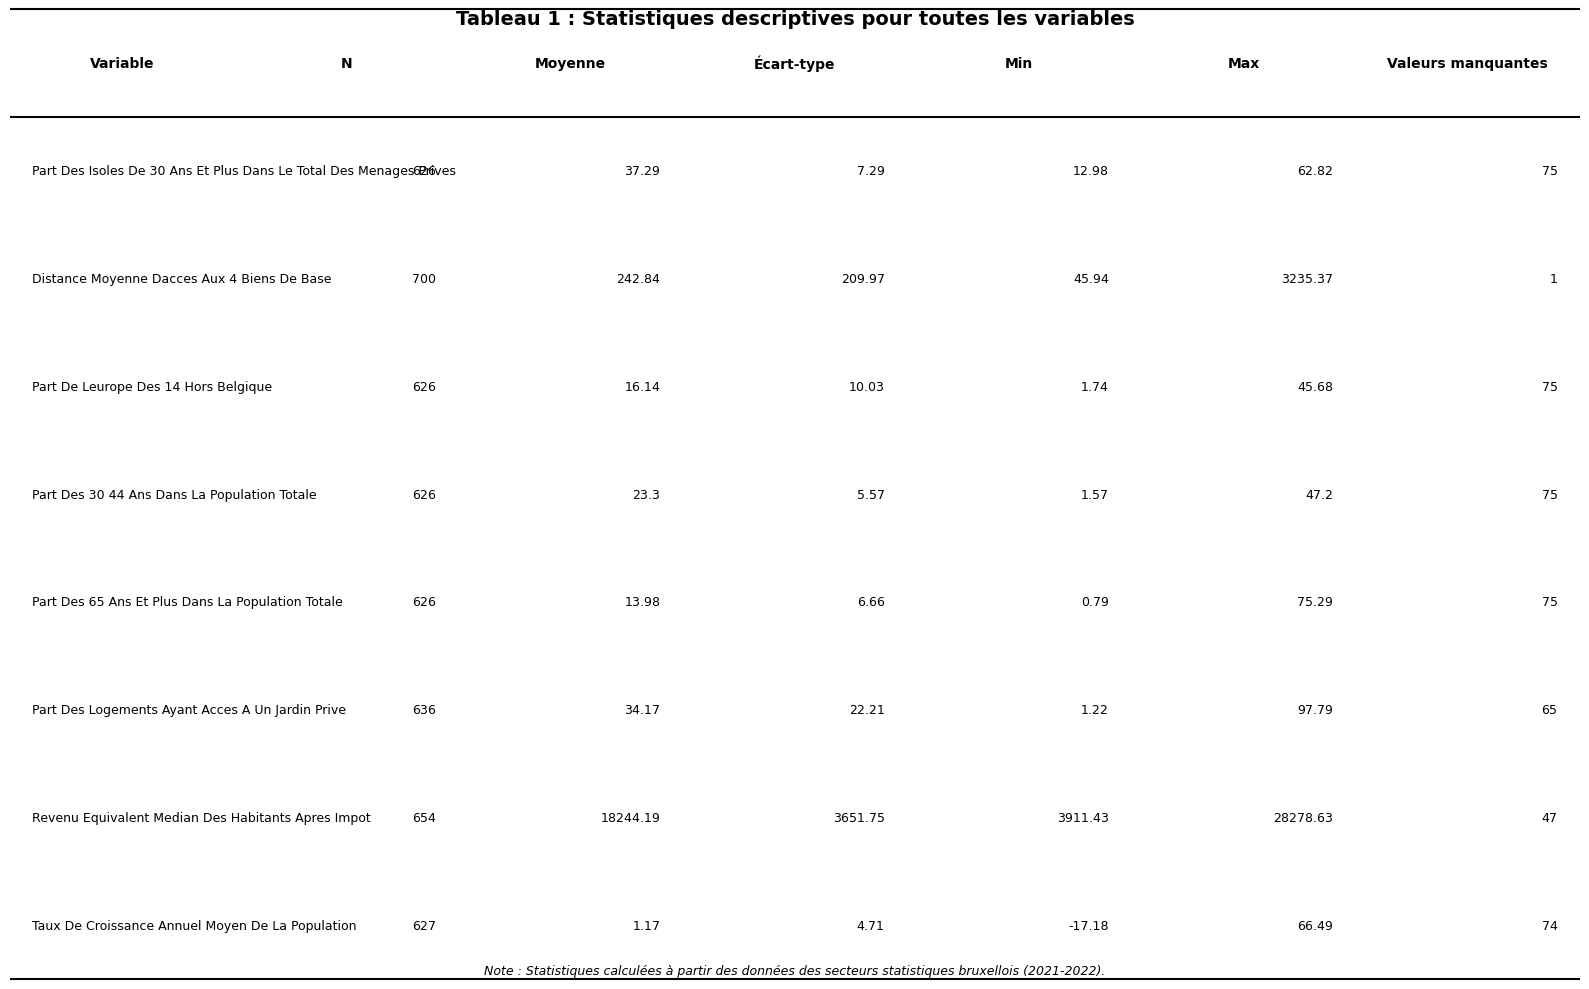

In [35]:
# Prepare data for analysis
analysis_df = gdf.pivot_table(
    index=['id', 'name'],
    columns='metric_name',
    values='value',
    aggfunc='first'
).reset_index()

# Replace dashes with underscores in column names
analysis_df.columns = [col.replace('-', '_') for col in analysis_df.columns]

# Define variables
dep_var_temp = 'part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives'
indep_vars_temp = [col for col in analysis_df.columns if col not in ['id', 'name', dep_var_temp]]

# Calculate summary statistics
print('='*80)
print('VARIABLE SUMMARY STATISTICS')
print('='*80)

summary_stats = []
for var in [dep_var_temp] + indep_vars_temp:
    var_data = analysis_df[var].dropna()
    summary_stats.append({
        'Variable': var,
        'N': len(var_data),
        'Moyenne': var_data.mean(),
        'Écart-type': var_data.std(),
        'Min': var_data.min(),
        'Max': var_data.max(),
        'Valeurs manquantes': len(analysis_df) - len(var_data)
    })

summary_df = pd.DataFrame(summary_stats)
print('\nTable: Descriptive Statistics for All Variables')
print('-'*80)
print(summary_df.to_string(index=False))
print('\n' + '='*80)

# Save to CSV
summary_df.to_csv('variable_summary_statistics.csv', index=False)
print('✓ Summary statistics saved to variable_summary_statistics.csv')

# Create a properly formatted table image following academic standards (Duke Economics guidelines)
# Key principles: minimal horizontal lines only, no vertical lines, clean professional appearance

fig, ax = plt.subplots(figsize=(16, 10))
ax.axis('off')

# Create display version with shorter variable names
summary_df_display = summary_df.copy()
summary_df_display['Variable'] = summary_df_display['Variable'].str.replace('_', ' ').str.title()

# Round values for cleaner display
summary_df_display['Moyenne'] = summary_df_display['Moyenne'].round(2)
summary_df_display['Écart-type'] = summary_df_display['Écart-type'].round(2)
summary_df_display['Min'] = summary_df_display['Min'].round(2)
summary_df_display['Max'] = summary_df_display['Max'].round(2)

# Create table with minimal styling
table = ax.table(cellText=summary_df_display.values,
                colLabels=summary_df_display.columns,
                cellLoc='left',
                loc='center',
                bbox=[0, 0, 1, 1])

# Style the table following academic standards
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.2)

# Remove all cell edges first
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('white')
    cell.set_facecolor('white')

# Style header row - bold, with line above and below
for i in range(len(summary_df_display.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', size=10)
    cell.set_facecolor('white')
    # Add top and bottom borders to header
    if i == 0:
        cell.visible_edges = 'TB'
    else:
        cell.visible_edges = 'TB'
    cell.set_linewidth(1.5)
    cell.set_edgecolor('black')

# Style data rows - left align variable names, right align numbers
for i in range(1, len(summary_df_display) + 1):
    for j in range(len(summary_df_display.columns)):
        cell = table[(i, j)]
        
        # Variable names left-aligned, numbers right-aligned
        if j == 0:  # Variable column
            cell.set_text_props(size=9, ha='left')
        else:  # Numeric columns
            cell.set_text_props(size=9, ha='right')
            cell._loc = 'right'
        
        # No borders on data cells
        cell.visible_edges = ''
        cell.set_facecolor('white')

# Add bottom border to last row
for i in range(len(summary_df_display.columns)):
    cell = table[(len(summary_df_display), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)
    cell.set_edgecolor('black')

# Add title and note
fig.text(0.5, 0.97, 'Tableau 1 : Statistiques descriptives pour toutes les variables', 
         ha='center', fontsize=14, fontweight='bold')
fig.text(0.5, 0.02, 'Note : Statistiques calculées à partir des données des secteurs statistiques bruxellois (2021-2022).', 
         ha='center', fontsize=9, style='italic')

plt.tight_layout()
plt.savefig('summary_statistics_table.png', dpi=300, bbox_inches='tight', facecolor='white')

print('✓ Summary statistics table saved as PNG (academic format): summary_statistics_table.png')

CORRELATION MATRIX ANALYSIS

Total variable pairs analyzed: 21
Highly correlated pairs (|r| > 0.7): 0

No variable pairs with |r| > 0.7 found.

✓ Correlation matrix heatmap saved to correlation_matrix_all_variables.png


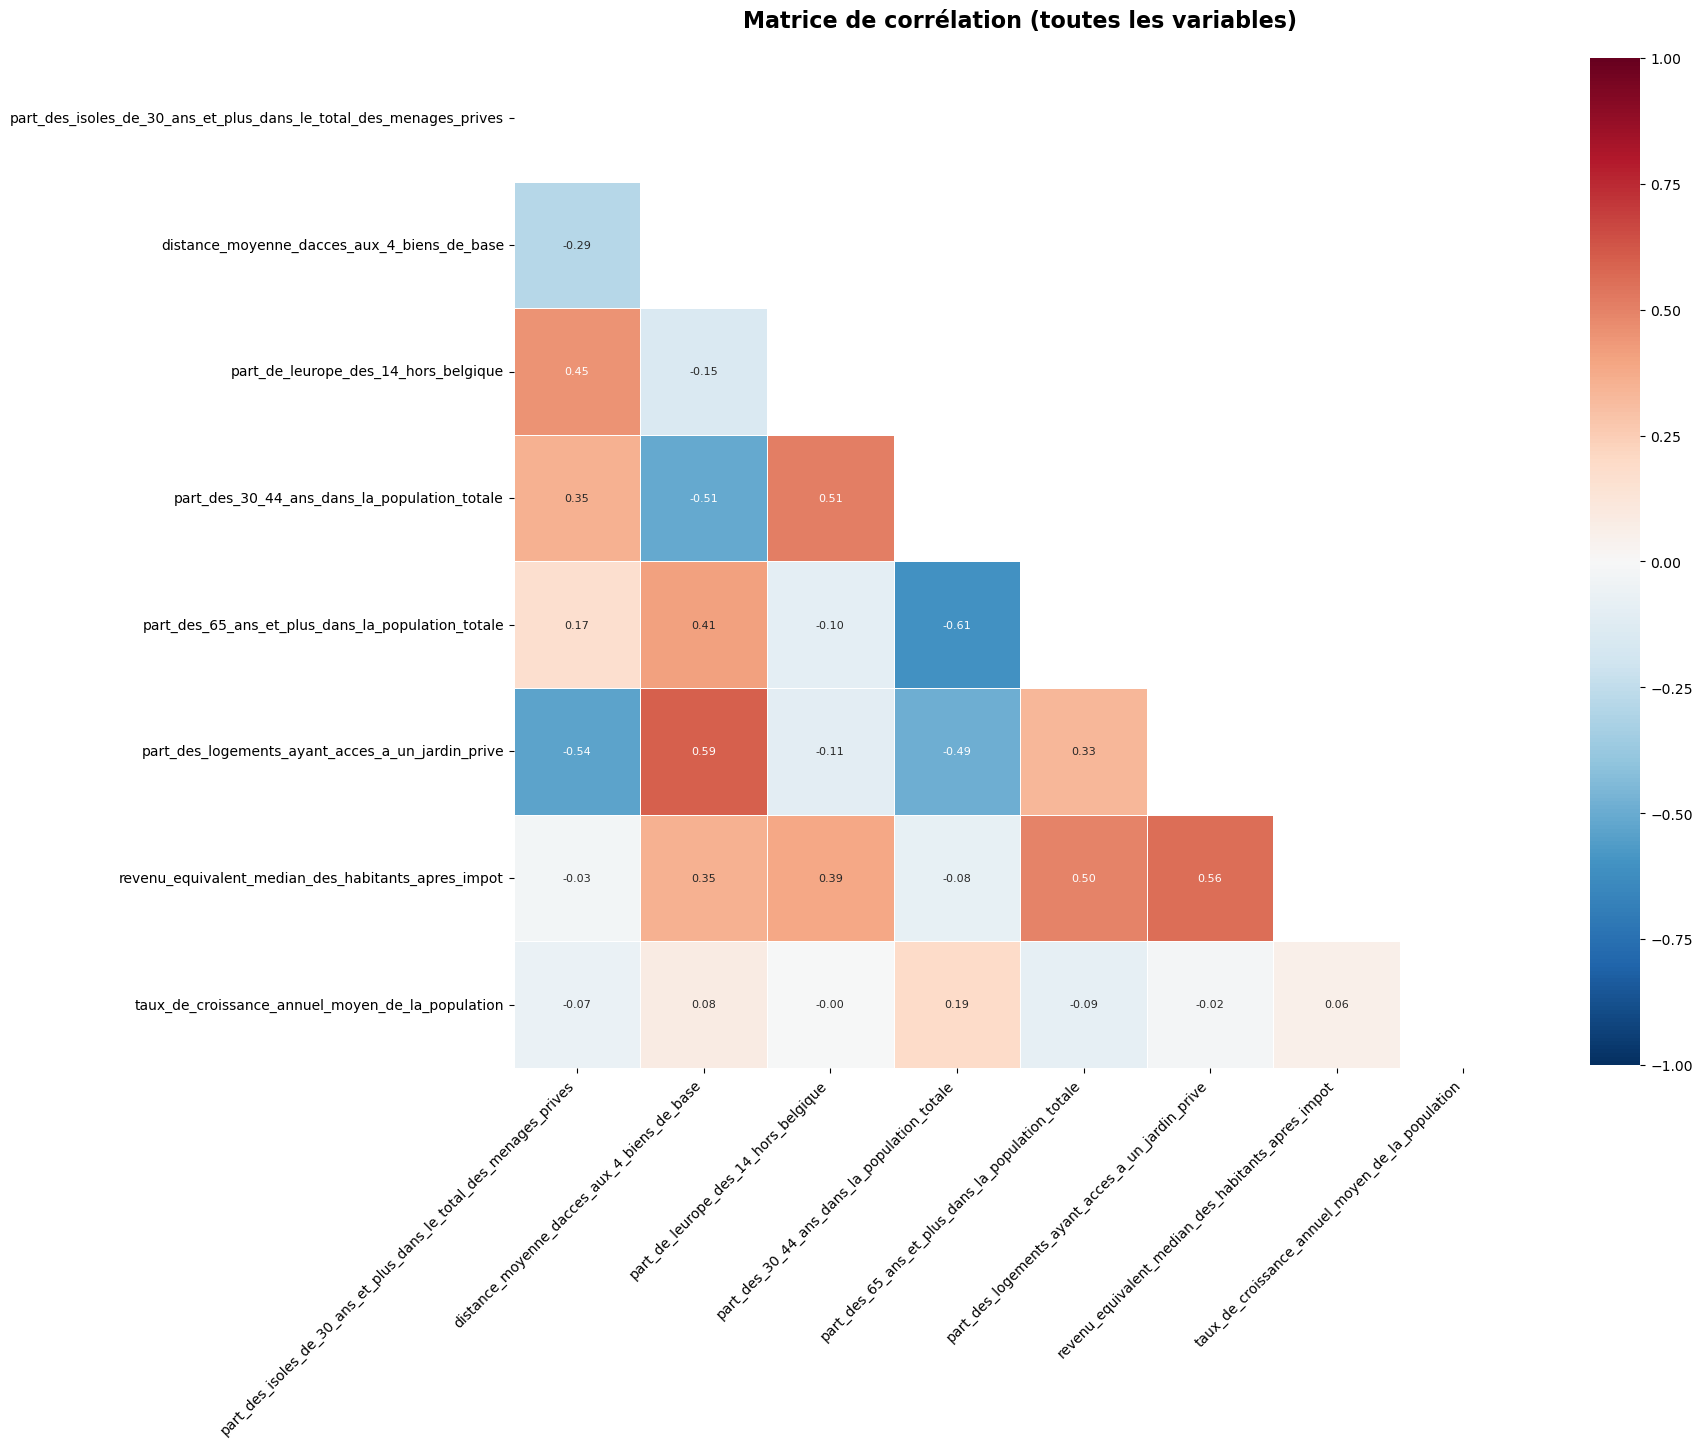

In [36]:
# Calculate correlation matrix for all variables (including dependent)
all_vars = [dep_var_temp] + indep_vars_temp
corr_data = analysis_df[all_vars].dropna()
corr_matrix = corr_data.corr()

print('='*80)
print('CORRELATION MATRIX ANALYSIS')
print('='*80)

# Find highly correlated pairs (r > 0.7) among independent variables only
high_corr_pairs = []
for i in range(len(indep_vars_temp)):
    for j in range(i+1, len(indep_vars_temp)):
        var1 = indep_vars_temp[i]
        var2 = indep_vars_temp[j]
        correlation = corr_matrix.loc[var1, var2]
        if abs(correlation) > 0.7:
            high_corr_pairs.append({
                'Variable 1': var1,
                'Variable 2': var2,
                'Correlation': correlation
            })

print(f'\nTotal variable pairs analyzed: {len(indep_vars_temp)*(len(indep_vars_temp)-1)//2}')
print(f'Highly correlated pairs (|r| > 0.7): {len(high_corr_pairs)}')

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    high_corr_df = high_corr_df.sort_values('Correlation', key=abs, ascending=False)
    
    print('\nHighly Correlated Variable Pairs (|r| > 0.7):')
    print('-'*80)
    print(high_corr_df.to_string(index=False))
    
    # Identify variables to potentially remove
    var_counts = {}
    for pair in high_corr_pairs:
        var_counts[pair['Variable 1']] = var_counts.get(pair['Variable 1'], 0) + 1
        var_counts[pair['Variable 2']] = var_counts.get(pair['Variable 2'], 0) + 1
    
    if var_counts:
        print('\nVariables appearing in multiple high-correlation pairs:')
        print('(Consider removing these to reduce multicollinearity)')
        print('-'*80)
        sorted_vars = sorted(var_counts.items(), key=lambda x: x[1], reverse=True)
        for var, count in sorted_vars:
            print(f'  • {var}: appears in {count} pair(s)')
    
    high_corr_df.to_csv('high_correlations_early.csv', index=False)
    print('\n✓ High correlations saved to high_correlations_early.csv')
else:
    print('\nNo variable pairs with |r| > 0.7 found.')

# Create correlation heatmap
fig, ax = plt.subplots(figsize=(18, 16))

# Create mask for upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot heatmap
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            ax=ax, annot_kws={'size': 8})

ax.set_title('Matrice de corrélation (toutes les variables)', fontsize=16, fontweight='bold', pad=20)

# Rotate labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('correlation_matrix_all_variables.png', dpi=300, bbox_inches='tight', facecolor='white')

print('\n✓ Correlation matrix heatmap saved to correlation_matrix_all_variables.png')
print('='*80)


## 5. Data Standardisation

In [37]:
# ============================================================================
# STANDARDISATION DES DONNÉES
# ============================================================================

print('='*80)
print('STANDARDISATION DES DONNÉES POUR RÉGRESSION')
print('='*80)

# Préparer les données pour régression
regression_df = gdf.pivot_table(
    index=['id', 'name'],
    columns='metric_name',
    values='value',
    aggfunc='first'
).reset_index()

# Replace dashes with underscores in column names
regression_df.columns = [col.replace('-', '_') for col in regression_df.columns]

# Define dependent variable
dep_var = 'part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives'

# Exclude highly correlated variables
excluded_vars = ['part_des_surfaces_impermeables', 
                'age_moyen',
                'concentrations_moyennes_annuelles_en_dioxyde_dazote_no2']
indep_vars = [col for col in regression_df.columns 
              if col not in ['id', 'name', dep_var] + excluded_vars]

print(f'\nVariables sélectionnées:')
print(f'  - Variable dépendante: 1')
print(f'  - Variables indépendantes: {len(indep_vars)}')
print(f'  - Variables exclues (corrélation): {len(excluded_vars)}')

# Prepare complete data
regression_data = regression_df[['id', 'name'] + indep_vars + [dep_var]].dropna()
print(f'  - Observations complètes: {len(regression_data)}')

# Separate X and y
X_original = regression_data[indep_vars].values
y_original = regression_data[dep_var].values

# Standardize (mean=0, std=1)
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_original)
y_scaled = scaler_y.fit_transform(y_original.reshape(-1, 1)).ravel()

# Create DataFrame with standardized data
regression_data_scaled = regression_data[['id', 'name']].copy()
for i, var in enumerate(indep_vars):
    regression_data_scaled[var] = X_scaled[:, i]
regression_data_scaled[dep_var] = y_scaled

# Store scalers and variable names for later use
standardization_info = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'indep_vars': indep_vars,
    'dep_var': dep_var,
    'n_obs': len(regression_data_scaled)
}

# Verification
print(f'\n✓ Standardisation réussie:')
print(f'  - X: mean={X_scaled.mean():.6f}, std={X_scaled.std():.6f}')
print(f'  - y: mean={y_scaled.mean():.6f}, std={y_scaled.std():.6f}')
print(f'  - Variables stockées: {len(indep_vars)} indépendantes + 1 dépendante')
print('='*80)

# Display summary
print(f'\nDonnées disponibles pour les analyses:')
print(f'  - regression_data: données originales ({regression_data.shape})')
print(f'  - regression_data_scaled: données standardisées ({regression_data_scaled.shape})')
print(f'  - standardization_info: informations de standardisation')

STANDARDISATION DES DONNÉES POUR RÉGRESSION

Variables sélectionnées:
  - Variable dépendante: 1
  - Variables indépendantes: 7
  - Variables exclues (corrélation): 3
  - Observations complètes: 613

✓ Standardisation réussie:
  - X: mean=-0.000000, std=1.000000
  - y: mean=0.000000, std=1.000000
  - Variables stockées: 7 indépendantes + 1 dépendante

Données disponibles pour les analyses:
  - regression_data: données originales ((613, 10))
  - regression_data_scaled: données standardisées ((613, 10))
  - standardization_info: informations de standardisation


## 6. OLS Regression Analysis

In [38]:
# ============================================================================
# RÉGRESSION OLS AVEC DONNÉES STANDARDISÉES
# ============================================================================

print('='*80)
print('RÉGRESSION OLS (DONNÉES STANDARDISÉES)')
print('='*80)

# Retrieve variables from standardization
dep_var = standardization_info['dep_var']
indep_vars = standardization_info['indep_vars']

print(f'Modèle: {len(indep_vars)} variables indépendantes')
print(f'Observations: {standardization_info["n_obs"]}')

# Fit OLS model with standardized data
formula = f'{dep_var} ~ ' + ' + '.join(indep_vars)
model = ols(formula, data=regression_data_scaled).fit()

# Display results
print('\n' + '-'*80)
print(model.summary())
print('-'*80)

# Extract key statistics
print(f'\nStatistiques clés:')
print(f'  R²: {model.rsquared:.4f}')
print(f'  R² ajusté: {model.rsquared_adj:.4f}')
print(f'  F-statistic: {model.fvalue:.2f} (p={model.f_pvalue:.2e})')
print(f'  AIC: {model.aic:.2f}')

# Significant variables
sig_vars = model.pvalues[model.pvalues < 0.05]
print(f'\nVariables significatives (p<0.05): {len(sig_vars)-1} (hors constante)')
for var in sig_vars.index[1:]:
    print(f'  • {var}: β={model.params[var]:+.4f}, p={model.pvalues[var]:.2e}')

print('\n' + '='*80)
print('NOTE: Coefficients standardisés (unités d\'écarts-types)')
print('      β = 0.5 signifie: +1 SD en X → +0.5 SD en Y')
print('='*80)

RÉGRESSION OLS (DONNÉES STANDARDISÉES)
Modèle: 7 variables indépendantes
Observations: 613

--------------------------------------------------------------------------------
                                                    OLS Regression Results                                                    
Dep. Variable:     part_des_isoles_de_30_ans_et_plus_dans_le_total_des_menages_prives   R-squared:                       0.645
Model:                                                                            OLS   Adj. R-squared:                  0.640
Method:                                                                 Least Squares   F-statistic:                     156.7
Date:                                                                Tue, 03 Mar 2026   Prob (F-statistic):          2.05e-131
Time:                                                                        22:38:18   Log-Likelihood:                -552.75
No. Observations:                                                

✓ Tableau OLS formaté sauvegardé: tableau_OLS_resultats.png

Aperçu du tableau:
                                         Variable   Coef. Err. std.      t    P>|t| IC 95% (inf.) IC 95% (sup.) Sig.
                                        Constante  0.0000    0.0242  0.000 1.00e+00       -0.0476        0.0476     
    Distance moyenne d'accès\naux 4 biens de base  0.0223    0.0327  0.681 4.96e-01       -0.0420        0.0866     
             part_de_leurope_des_14_hors_belgique  0.3874    0.0337 11.512 7.21e-28        0.3213        0.4535  ***
     part_des_30_44_ans_dans_la_population_totale  0.3759    0.0466  8.062 4.04e-15        0.2844        0.4675  ***
part_des_65_ans_et_plus_dans_la_population_totale  0.6857    0.0412 16.647 1.66e-51        0.6048        0.7666  ***
            Part des logements\navec jardin privé -0.4061    0.0409 -9.934 1.21e-21       -0.4863       -0.3258  ***
            Revenu équivalent médian\naprès impôt -0.2679    0.0446 -6.007 3.26e-09       -0.3555    

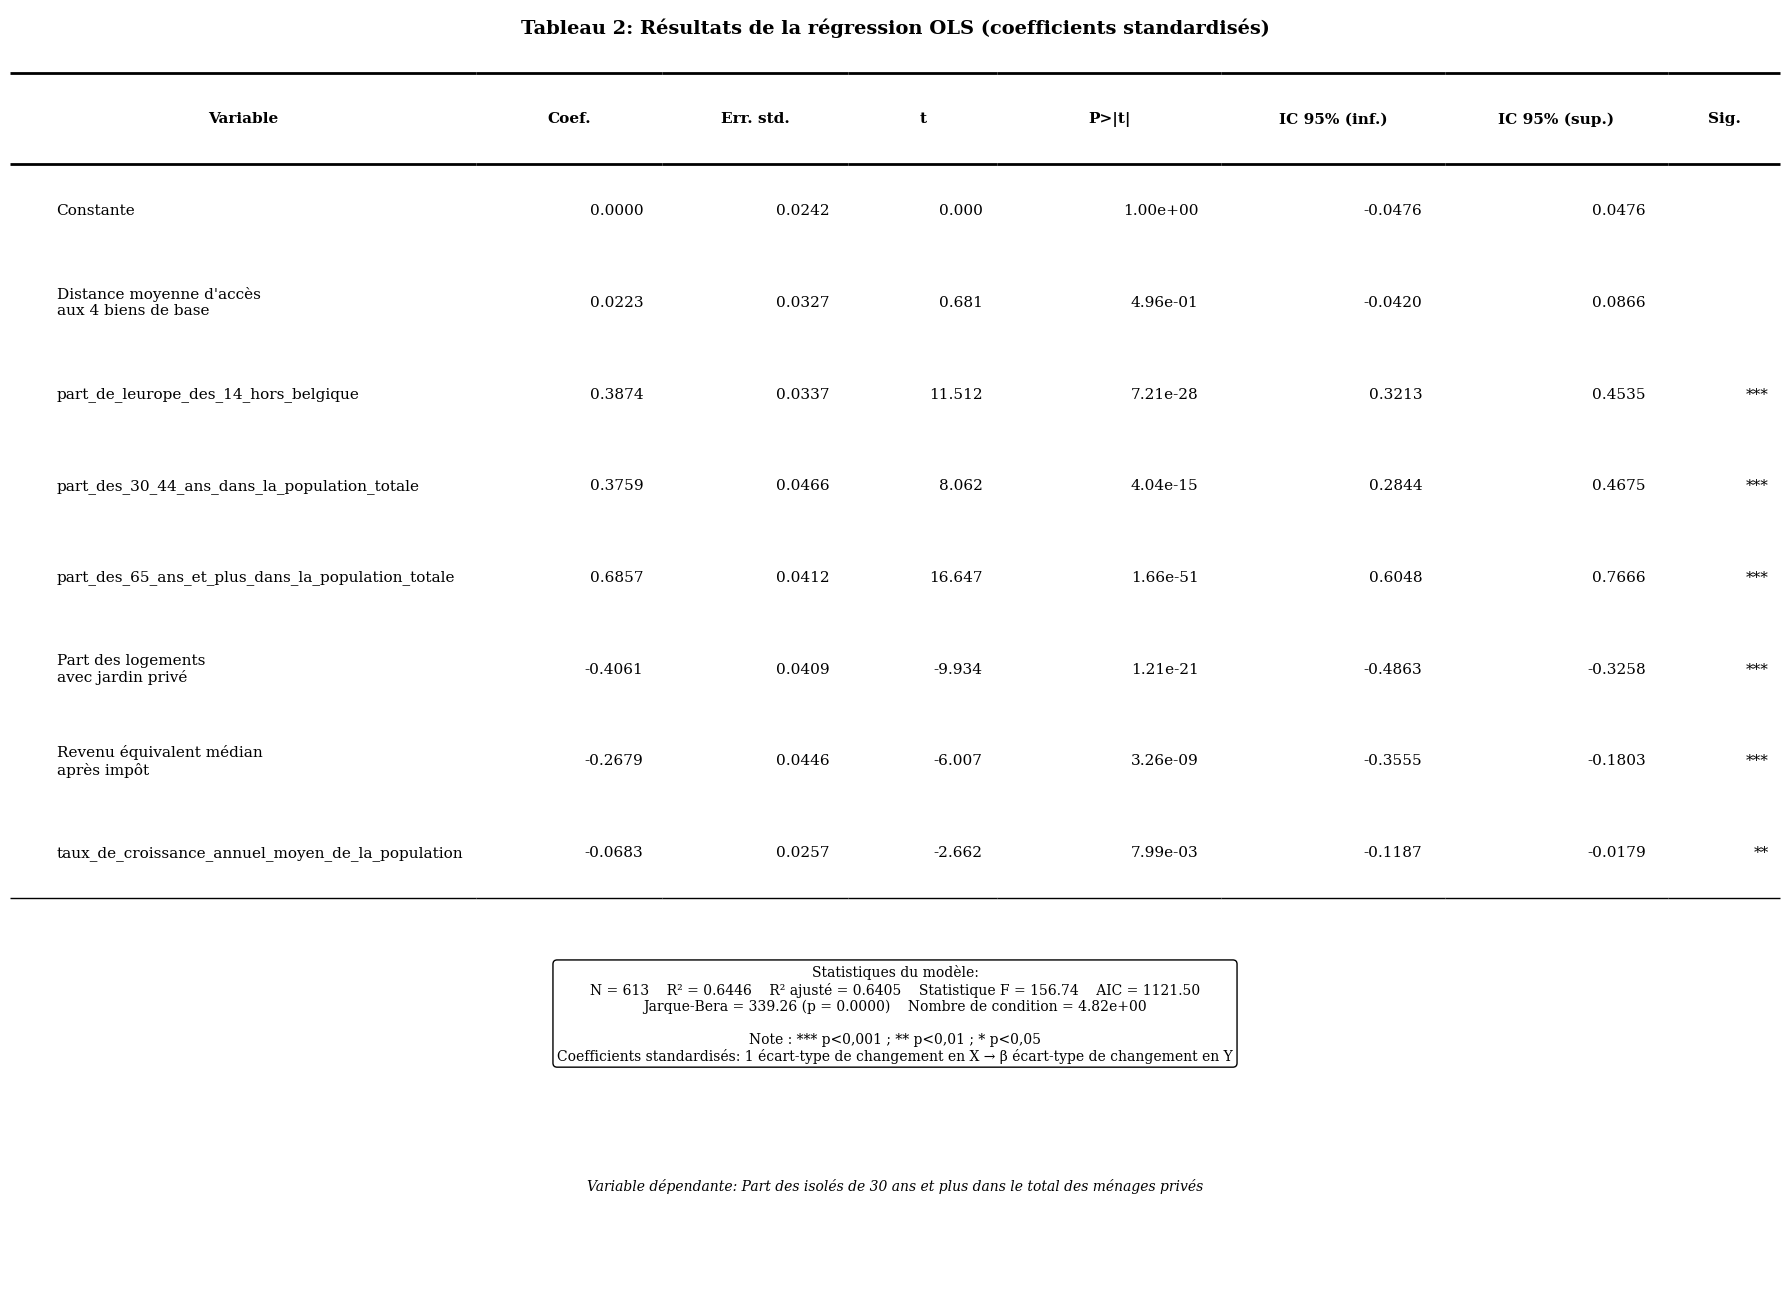

In [39]:
# Create academic-style OLS results table following APA/journal standards

# Import Jarque-Bera test
from statsmodels.stats.stattools import jarque_bera

# Dictionary for French variable names (with line breaks for long names)
var_names_fr = {
    'Intercept': 'Constante',
    'densite_de_bureaux': 'Densité de bureaux',
    'densite_des_menages_prives': 'Densité des\nménages privés',
    'distance_moyenne_dacces_aux_4_biens_de_base': 'Distance moyenne d\'accès\naux 4 biens de base',
    'part_de_la_population_a_proximite_dun_arret_de_transport_en_commun_3_modes_confondus': 'Part de la pop. à prox.\ntransports en commun',
    'part_de_la_population_a_proximite_dun_espace_vert_accessible_au_public': 'Part de la pop. à prox.\nespaces verts',
    'part_de_la_voirie_dediee_au_trottoir': 'Part de la voirie\ndédiée au trottoir',
    'part_des_isoles_de_65_ans_et_plus_dans_le_total_des_menages_prives': 'Part des isolés 65+\ndans les ménages privés',
    'part_des_logements_ayant_acces_a_un_jardin_prive': 'Part des logements\navec jardin privé',
    'population_des_18_29_ans': 'Population des\n18-29 ans',
    'revenu_equivalent_median_des_habitants_apres_impot': 'Revenu équivalent médian\naprès impôt',
    'taux_de_vegetalisation': 'Taux de\nvégétalisation',
    'taux_demploi': 'Taux d\'emploi'
}

# Extract model results
results_data = []
for var in model.params.index:
    coef = model.params[var]
    std_err = model.bse[var]
    t_stat = model.tvalues[var]
    p_value = model.pvalues[var]
    ci_lower = model.conf_int().loc[var, 0]
    ci_upper = model.conf_int().loc[var, 1]
    
    # Significance stars
    if p_value < 0.001:
        sig = '***'
    elif p_value < 0.01:
        sig = '**'
    elif p_value < 0.05:
        sig = '*'
    else:
        sig = ''
    
    # French variable name
    var_fr = var_names_fr.get(var, var)
    
    results_data.append({
        'Variable': var_fr,
        'Coef.': f'{coef:.4f}',
        'Err. std.': f'{std_err:.4f}',
        't': f'{t_stat:.3f}',
        'P>|t|': f'{p_value:.2e}',
        'IC 95% (inf.)': f'{ci_lower:.4f}',
        'IC 95% (sup.)': f'{ci_upper:.4f}',
        'Sig.': sig
    })

results_df = pd.DataFrame(results_data)

# Create the table figure with adjusted width
fig = plt.figure(figsize=(18, 13))
ax = fig.add_subplot(111)
ax.axis('off')

# Create table with custom column widths
# First column wider to accommodate two-line variable names
colWidths = [0.25, 0.10, 0.10, 0.08, 0.12, 0.12, 0.12, 0.06]

table = ax.table(cellText=results_df.values,
                colLabels=results_df.columns,
                cellLoc='left',
                loc='center',
                colWidths=colWidths,
                bbox=[0, 0.3, 1, 0.65])

# Set font to serif (Times-like)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2.8)  # Increased vertical scale for two-line names

# Style all cells - white background, no borders initially
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

# Style header row - bold with top and bottom lines
for i in range(len(results_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', family='serif', size=11, va='center')
    cell.set_facecolor('white')
    
    # Top line (double) and bottom line (simple)
    cell.visible_edges = 'TB'
    cell.set_linewidth(1.0)

# Add double line at top of header
for i in range(len(results_df.columns)):
    cell = table[(0, i)]
    # Simulate double line by adding extra weight
    cell.set_linewidth(2.0)

# Style data rows
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=11, va='center')
        
        # Left align variables, right align numbers
        if j == 0:  # Variable column
            cell.set_text_props(ha='left', family='serif', size=11, va='center')
        else:  # Numeric columns
            cell.set_text_props(ha='right', family='serif', size=11, va='center')
            cell._loc = 'right'
        
        # No borders on data cells
        cell.visible_edges = ''

# Add bottom border to last row before stats
for i in range(len(results_df.columns)):
    cell = table[(len(results_df), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.0)

# Calculate Jarque-Bera test on residuals
jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(model.resid)

# Add model statistics below the table
stats_text = f'''Statistiques du modèle:
N = {int(model.nobs)}    R² = {model.rsquared:.4f}    R² ajusté = {model.rsquared_adj:.4f}    Statistique F = {model.fvalue:.2f}    AIC = {model.aic:.2f}
Jarque-Bera = {jb_stat:.2f} (p = {jb_pvalue:.4f})    Nombre de condition = {model.condition_number:.2e}

Note : *** p<0,001 ; ** p<0,01 ; * p<0,05
Coefficients standardisés: 1 écart-type de changement en X → β écart-type de changement en Y'''

fig.text(0.5, 0.18, stats_text, ha='center', fontsize=10, family='serif', 
         bbox=dict(boxstyle='round', facecolor='white', edgecolor='black', linewidth=1.0))

# Add title
fig.text(0.5, 0.97, 'Tableau 2: Résultats de la régression OLS (coefficients standardisés)', 
         ha='center', fontsize=14, fontweight='bold', family='serif')

# Add footnote
fig.text(0.5, 0.08, 
         'Variable dépendante: Part des isolés de 30 ans et plus dans le total des ménages privés',
         ha='center', fontsize=10, style='italic', family='serif')

plt.tight_layout()
plt.savefig('tableau_OLS_resultats.png', dpi=300, bbox_inches='tight', facecolor='white')


print('✓ Tableau OLS formaté sauvegardé: tableau_OLS_resultats.png')
print(f'\nAperçu du tableau:')
print(results_df.to_string(index=False))
print(f'\nStatistiques additionnelles:')
print(f'  Jarque-Bera: {jb_stat:.2f} (p = {jb_pvalue:.4f})')
print(f'  Condition Number: {model.condition_number:.2e}')
print(f'\n⚠ IMPORTANT: Les coefficients sont standardisés (en unités d\'écarts-types)')

Vérification des dépendances...
✓ libpysal déjà installé
✓ esda déjà installé
✓ splot déjà installé

ÉTAPE 1: MORAN'S I SUR LA VARIABLE DÉPENDANTE BRUTE
Nombre d'observations spatiales: 626
Matrice de poids W: 5.56 voisins en moyenne

RÉSULTATS - Variable dépendante:
  Moran's I:     0.4020
  E(I):          -0.0016
  Variance:      0.000625
  Z-score:       16.1456
  P-value:       1.2203e-58
  Significativité: ***
  Interprétation: Autocorrélation spatiale positive (clustering)

ÉTAPE 2: MORAN'S I SUR LES RÉSIDUS DU MODÈLE OLS
Nombre d'observations avec résidus: 613
Matrice de poids W: 5.49 voisins en moyenne

RÉSULTATS - Résidus OLS:
  Moran's I:     0.2366
  E(I):          -0.0016
  Variance:      0.000644
  Z-score:       9.3918
  P-value:       5.8994e-21
  Significativité: ***
  ⚠ Autocorrélation résiduelle significative → Modèle spatial justifié (GWR, SAR, CAR)

COMPARAISON DES DEUX TESTS
Variable dépendante:  I = 0.4020 ***, p = 1.2203e-58
Résidus OLS:          I = 0.2366 ***, 

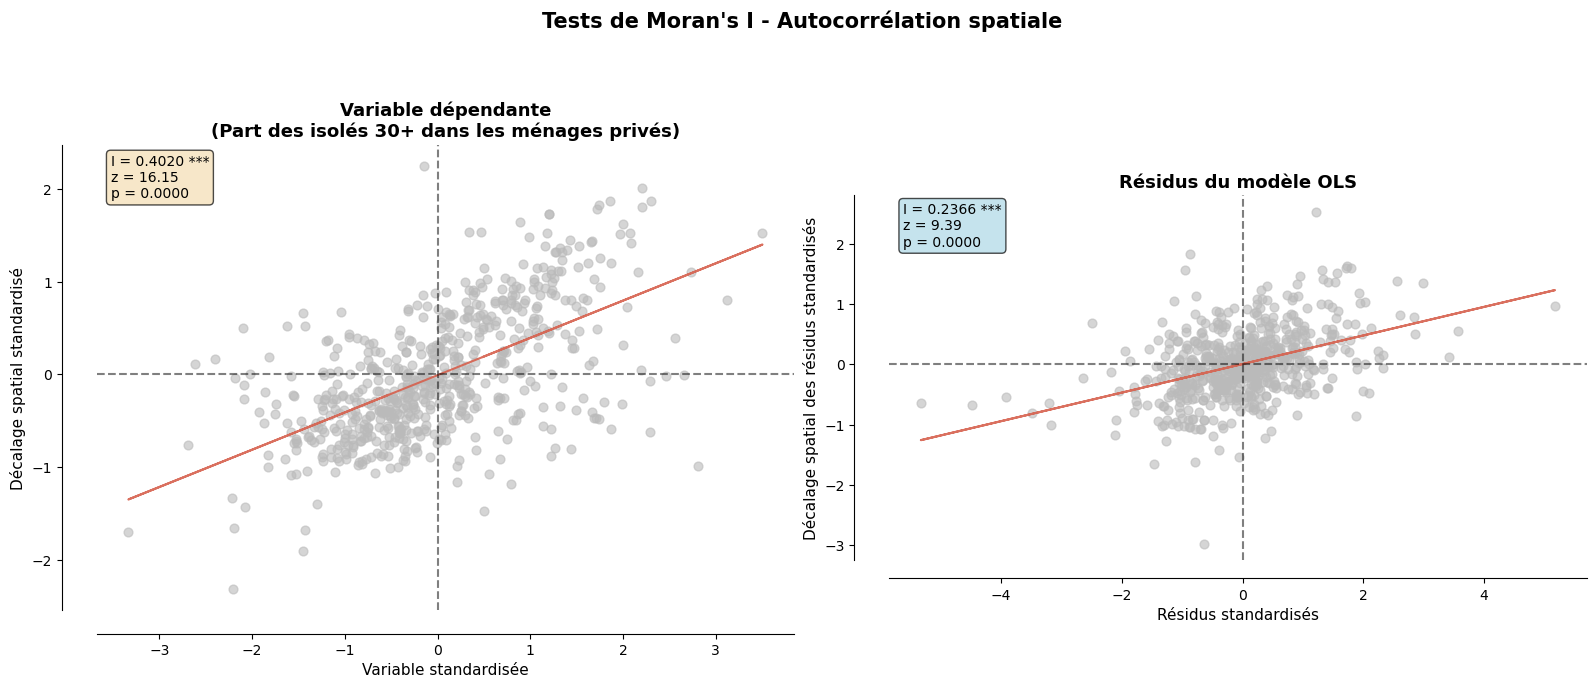


✓ Visualisation sauvegardée: moran_tests_comparison.png


In [40]:
# ============================================================================
# TESTS D'AUTOCORRÉLATION SPATIALE - MORAN'S I
# ============================================================================

# Installation des packages nécessaires AVANT les imports
import sys
import subprocess

def install_package(package):
    """Installe un package si non présent"""
    try:
        __import__(package.replace('-', '_'))
        print(f'✓ {package} déjà installé')
    except ImportError:
        print(f'Installation de {package}...')
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package])
        print(f'✓ {package} installé avec succès')

# Installer les packages nécessaires
print('Vérification des dépendances...')
for pkg in ['libpysal', 'esda', 'splot']:
    install_package(pkg)

print('\n' + '='*80)

# Maintenant importer les librairies (après installation)
from libpysal.weights import Queen
from esda.moran import Moran
import splot
from splot.esda import moran_scatterplot

# ----------------------------------------------------------------------------
# ÉTAPE 1: MORAN'S I SUR LA VARIABLE DÉPENDANTE BRUTE
# ----------------------------------------------------------------------------

print('ÉTAPE 1: MORAN\'S I SUR LA VARIABLE DÉPENDANTE BRUTE')
print('='*80)

# Préparer le GeoDataFrame avec la variable dépendante
gdf_spatial = gdf[gdf['metric_name'] == 'part-des-isoles-de-30-ans-et-plus-dans-le-total-des-menages-prives'].copy()
gdf_spatial = gdf_spatial[['id', 'name', 'geometry', 'value']].dropna()
gdf_spatial = gpd.GeoDataFrame(gdf_spatial, geometry='geometry', crs='EPSG:31370')

print(f'Nombre d\'observations spatiales: {len(gdf_spatial)}')

# Construire la matrice de poids spatiaux W avec contiguïté Queen
w = Queen.from_dataframe(gdf_spatial)
w.transform = 'r'  # Standardisation en ligne

print(f'Matrice de poids W: {w.mean_neighbors:.2f} voisins en moyenne')

# Calculer le Moran's I sur la variable dépendante
y = gdf_spatial['value'].values
moran_y = Moran(y, w)

# Afficher les résultats
print('\nRÉSULTATS - Variable dépendante:')
print(f'  Moran\'s I:     {moran_y.I:.4f}')
print(f'  E(I):          {moran_y.EI:.4f}')
print(f'  Variance:      {moran_y.VI_norm:.6f}')
print(f'  Z-score:       {moran_y.z_norm:.4f}')
print(f'  P-value:       {moran_y.p_norm:.4e}')

if moran_y.p_norm < 0.001:
    sig = '***'
elif moran_y.p_norm < 0.01:
    sig = '**'
elif moran_y.p_norm < 0.05:
    sig = '*'
else:
    sig = 'ns'

print(f'  Significativité: {sig}')
print(f'  Interprétation: {"Autocorrélation spatiale positive (clustering)" if moran_y.I > 0 else "Autocorrélation spatiale négative"}')

# ----------------------------------------------------------------------------
# ÉTAPE 2: MORAN'S I SUR LES RÉSIDUS DU MODÈLE OLS
# ----------------------------------------------------------------------------

print('\n' + '='*80)
print('ÉTAPE 2: MORAN\'S I SUR LES RÉSIDUS DU MODÈLE OLS')
print('='*80)

# Récupérer les résidus du modèle OLS et merger avec géométries
residuals_with_id = regression_data[['id', 'name']].copy()
residuals_with_id['residuals'] = model.resid.values

gdf_residuals = gdf_spatial[['id', 'geometry']].merge(residuals_with_id, on='id', how='inner')
gdf_residuals = gpd.GeoDataFrame(gdf_residuals, geometry='geometry', crs='EPSG:31370')

print(f'Nombre d\'observations avec résidus: {len(gdf_residuals)}')

# Construire matrice W pour les résidus
w_resid = Queen.from_dataframe(gdf_residuals)
w_resid.transform = 'r'

print(f'Matrice de poids W: {w_resid.mean_neighbors:.2f} voisins en moyenne')

# Calculer le Moran's I sur les résidus
residuals = gdf_residuals['residuals'].values
moran_resid = Moran(residuals, w_resid)

# Afficher les résultats
print('\nRÉSULTATS - Résidus OLS:')
print(f'  Moran\'s I:     {moran_resid.I:.4f}')
print(f'  E(I):          {moran_resid.EI:.4f}')
print(f'  Variance:      {moran_resid.VI_norm:.6f}')
print(f'  Z-score:       {moran_resid.z_norm:.4f}')
print(f'  P-value:       {moran_resid.p_norm:.4e}')

if moran_resid.p_norm < 0.001:
    sig_resid = '***'
elif moran_resid.p_norm < 0.01:
    sig_resid = '**'
elif moran_resid.p_norm < 0.05:
    sig_resid = '*'
else:
    sig_resid = 'ns'

print(f'  Significativité: {sig_resid}')

if moran_resid.p_norm < 0.05:
    print('  ⚠ Autocorrélation résiduelle significative → Modèle spatial justifié (GWR, SAR, CAR)')
else:
    print('  ✓ Pas d\'autocorrélation résiduelle → OLS approprié')

# ----------------------------------------------------------------------------
# COMPARAISON ET VISUALISATION
# ----------------------------------------------------------------------------

print('\n' + '='*80)
print('COMPARAISON DES DEUX TESTS')
print('='*80)
print(f'Variable dépendante:  I = {moran_y.I:.4f} {sig}, p = {moran_y.p_norm:.4e}')
print(f'Résidus OLS:          I = {moran_resid.I:.4f} {sig_resid}, p = {moran_resid.p_norm:.4e}')
print(f'Réduction autocorrélation: {(1 - abs(moran_resid.I)/abs(moran_y.I))*100:.1f}%')
print('='*80)

# Créer les Moran scatterplots côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Scatterplot 1: Variable dépendante
moran_scatterplot(moran_y, ax=axes[0])
axes[0].set_title('Variable dépendante\n(Part des isolés 30+ dans les ménages privés)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Variable standardisée', fontsize=11)
axes[0].set_ylabel('Décalage spatial standardisé', fontsize=11)
stats_text_y = f'I = {moran_y.I:.4f} {sig}\nz = {moran_y.z_norm:.2f}\np = {moran_y.p_norm:.4f}'
axes[0].text(0.02, 0.98, stats_text_y, transform=axes[0].transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

# Scatterplot 2: Résidus OLS
moran_scatterplot(moran_resid, ax=axes[1])
axes[1].set_title('Résidus du modèle OLS', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Résidus standardisés', fontsize=11)
axes[1].set_ylabel('Décalage spatial des résidus standardisés', fontsize=11)
stats_text_resid = f'I = {moran_resid.I:.4f} {sig_resid}\nz = {moran_resid.z_norm:.2f}\np = {moran_resid.p_norm:.4f}'
axes[1].text(0.02, 0.98, stats_text_resid, transform=axes[1].transAxes, 
            fontsize=10, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7))

plt.suptitle('Tests de Moran\'s I - Autocorrélation spatiale', fontsize=15, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('moran_tests_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('\n✓ Visualisation sauvegardée: moran_tests_comparison.png')

✓ Diagnostic plots saved


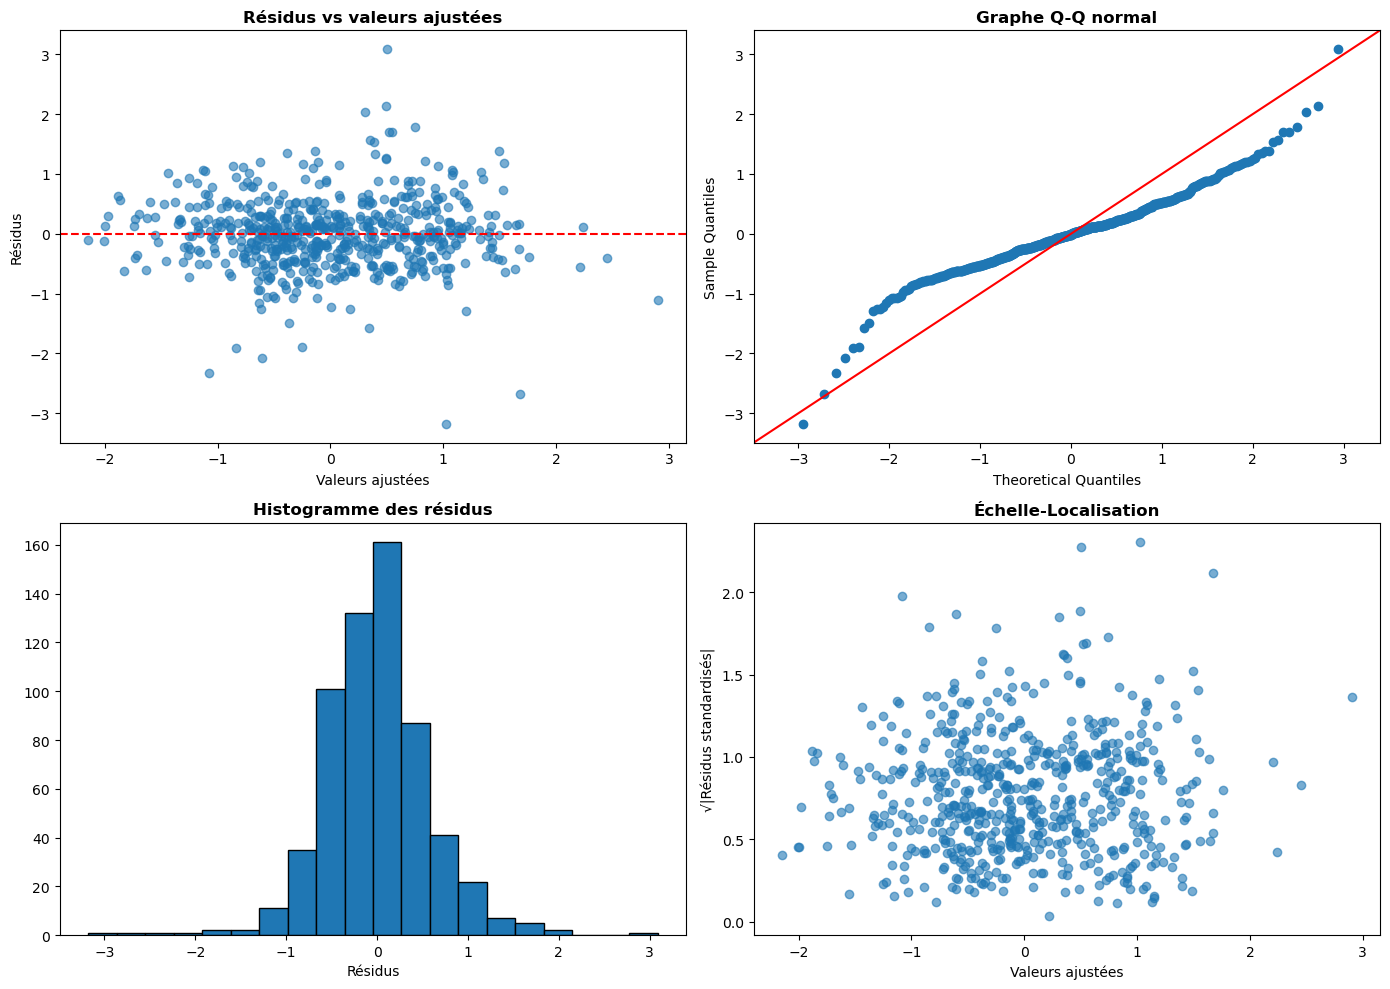

In [41]:
# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals vs Fitted
axes[0, 0].scatter(model.fittedvalues, model.resid, alpha=0.6)
axes[0, 0].axhline(y=0, color='r', linestyle='--')
axes[0, 0].set_title('Résidus vs valeurs ajustées', fontweight='bold')
axes[0, 0].set_xlabel('Valeurs ajustées')
axes[0, 0].set_ylabel('Résidus')

# Q-Q plot
sm.qqplot(model.resid, line='45', ax=axes[0, 1])
axes[0, 1].set_title('Graphe Q-Q normal', fontweight='bold')

# Histogram of residuals
axes[1, 0].hist(model.resid, bins=20, edgecolor='black')
axes[1, 0].set_title('Histogramme des résidus', fontweight='bold')
axes[1, 0].set_xlabel('Résidus')

# Scale-Location
standardized_resid = model.resid / model.resid.std()
axes[1, 1].scatter(model.fittedvalues, np.sqrt(np.abs(standardized_resid)), alpha=0.6)
axes[1, 1].set_title('Échelle-Localisation', fontweight='bold')
axes[1, 1].set_xlabel('Valeurs ajustées')
axes[1, 1].set_ylabel('√|Résidus standardisés|')

plt.tight_layout()
plt.savefig('regression_diagnostics.png', dpi=150, bbox_inches='tight')
print('✓ Diagnostic plots saved')

## 6 GWR Regression Analysis

In [42]:
# ============================================================================
# RÉGRESSION GWR AVEC DONNÉES STANDARDISÉES
# ============================================================================

print('='*80)
print('GWR REGRESSION ANALYSIS (DONNÉES STANDARDISÉES)')
print('='*80)

# Utiliser les données déjà standardisées de la section 4.5
dep_var = standardization_info['dep_var']
indep_vars = standardization_info['indep_vars']

print(f'Utilisation des données standardisées existantes:')
print(f'  - Variables indépendantes: {len(indep_vars)}')
print(f'  - Observations: {len(regression_data_scaled)}')

# Préparer le GeoDataFrame avec les données standardisées
# Merger les données standardisées avec les géométries
gdf_gwr = gdf[gdf['metric_name'] == 'part-des-isoles-de-30-ans-et-plus-dans-le-total-des-menages-prives'][['id', 'geometry']].copy()
gdf_gwr = gdf_gwr.merge(regression_data_scaled, on='id', how='inner')
gdf_gwr = gpd.GeoDataFrame(gdf_gwr, geometry='geometry', crs='EPSG:31370')

print(f'\nGeoDataFrame GWR créé: {len(gdf_gwr)} observations avec géométries')

# Extraire les coordonnées des centroïdes
coords = np.column_stack([gdf_gwr.geometry.centroid.x, gdf_gwr.geometry.centroid.y])
print(f'Coordonnées extraites: {coords.shape}')

# Extraire X et y (déjà standardisés)
X = gdf_gwr[indep_vars].values
y = gdf_gwr[dep_var].values

print(f'\nVérification standardisation:')
print(f'  - X: mean={X.mean():.6f}, std={X.std():.6f}')
print(f'  - y: mean={y.mean():.6f}, std={y.std():.6f}')

# Calculer la bandwidth
distances = cdist(coords, coords)
k = int(np.sqrt(len(coords)))
bandwidth = np.sort(distances, axis=1)[:, k].mean()

print(f'\nBandwidth GWR:')
print(f'  - Nombre de voisins (k): {k}')
print(f'  - Bandwidth: {bandwidth:.2f}m')
print('='*80)

GWR REGRESSION ANALYSIS (DONNÉES STANDARDISÉES)
Utilisation des données standardisées existantes:
  - Variables indépendantes: 7
  - Observations: 613

GeoDataFrame GWR créé: 613 observations avec géométries
Coordonnées extraites: (613, 2)

Vérification standardisation:
  - X: mean=-0.000000, std=1.000000
  - y: mean=0.000000, std=1.000000

Bandwidth GWR:
  - Nombre de voisins (k): 24
  - Bandwidth: 1332.05m


In [43]:
# Fit local regression models
print('Fitting local models...', end=' ')
n_obs = len(coords)
n_vars = X_scaled.shape[1]

local_coefs = np.zeros((n_obs, n_vars + 1))
local_r2 = np.zeros(n_obs)
local_resid = np.zeros(n_obs)

for i in range(n_obs):
    weights = np.exp(-(distances[i, :] / bandwidth) ** 2)
    try:
        model_local = LinearRegression()
        model_local.fit(X_scaled, y_scaled, sample_weight=weights)
        local_coefs[i, 0] = model_local.intercept_
        local_coefs[i, 1:] = model_local.coef_
        
        y_pred = model_local.predict(X_scaled)
        local_resid[i] = y_scaled[i] - y_pred[i]
        ss_res = np.sum(weights * (y_scaled - y_pred) ** 2)
        ss_tot = np.sum(weights * (y_scaled - np.mean(y_scaled)) ** 2)
        local_r2[i] = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
    except:
        pass

print(f'✓')

# Add results to GeoDataFrame
gdf_gwr['local_r2'] = local_r2
gdf_gwr['residuals'] = local_resid
for i, var in enumerate(indep_vars):
    gdf_gwr[f'coef_{var}'] = local_coefs[:, i+1]

print(f'Local R² mean: {gdf_gwr["local_r2"].mean():.4f} (range: {gdf_gwr["local_r2"].min():.4f}-{gdf_gwr["local_r2"].max():.4f})')

Fitting local models... ✓
Local R² mean: 0.7424 (range: 0.5713-0.9613)


In [44]:
# Ajuster les modèles locaux GWR (utilise les données standardisées de section 4.5)
print('Ajustement des modèles locaux GWR...')

# Utiliser les données standardisées déjà créées
# X et y viennent de gdf_gwr qui contient les données standardisées de regression_data_scaled
n_obs = len(coords)
n_vars = X.shape[1]

local_coefs = np.zeros((n_obs, n_vars + 1))
local_r2 = np.zeros(n_obs)
local_resid = np.zeros(n_obs)
local_cond_numbers = np.zeros(n_obs)  # Ajouter condition numbers

# Barre de progression
from time import time
start_time = time()

for i in range(n_obs):
    # Calculer les poids spatiaux
    weights = np.exp(-(distances[i, :] / bandwidth) ** 2)
    
    try:
        # Ajuster le modèle local pondéré
        model_local = LinearRegression()
        model_local.fit(X, y, sample_weight=weights)
        
        # Stocker les coefficients
        local_coefs[i, 0] = model_local.intercept_
        local_coefs[i, 1:] = model_local.coef_
        
        # Calculer les prédictions et résidus
        y_pred = model_local.predict(X)
        local_resid[i] = y[i] - y_pred[i]
        
        # Calculer R² local (pondéré)
        ss_res = np.sum(weights * (y - y_pred) ** 2)
        ss_tot = np.sum(weights * (y - np.mean(y)) ** 2)
        local_r2[i] = 1 - (ss_res / ss_tot) if ss_tot > 0 else 0
        
        # Calculer le Condition Number local
        W_sqrt = np.diag(np.sqrt(weights))
        X_weighted = W_sqrt @ X
        try:
            U, s, Vt = np.linalg.svd(X_weighted, full_matrices=False)
            cond_num = s.max() / s.min() if s.min() > 1e-10 else np.inf
            local_cond_numbers[i] = cond_num
        except:
            local_cond_numbers[i] = np.inf
        
    except:
        # En cas d'erreur, utiliser NaN
        local_coefs[i, :] = np.nan
        local_r2[i] = np.nan
        local_resid[i] = np.nan
        local_cond_numbers[i] = np.inf
    
    # Progression tous les 10%
    if (i + 1) % max(1, n_obs // 10) == 0:
        pct = (i + 1) / n_obs * 100
        print(f'  {pct:.0f}% complété...')

elapsed = time() - start_time
print(f'✓ Modèles locaux ajustés en {elapsed:.1f}s')

# Ajouter les résultats au GeoDataFrame
gdf_gwr['local_r2'] = local_r2
gdf_gwr['residuals'] = local_resid
gdf_gwr['intercept'] = local_coefs[:, 0]
gdf_gwr['condition_number'] = local_cond_numbers  # Ajouter condition number

for i, var in enumerate(indep_vars):
    gdf_gwr[f'coef_{var}'] = local_coefs[:, i+1]

# Statistiques
valid_cond = local_cond_numbers[np.isfinite(local_cond_numbers)]
print(f'\nStatistiques GWR:')
print(f'  R² local moyen: {np.nanmean(local_r2):.4f}')
print(f'  R² local range: [{np.nanmin(local_r2):.4f}, {np.nanmax(local_r2):.4f}]')
print(f'  Condition Number moyen: {valid_cond.mean():.2f}')
print(f'  Condition Number médian: {np.median(valid_cond):.2f}')
print(f'  Condition Number range: [{valid_cond.min():.2f}, {valid_cond.max():.2f}]')

Ajustement des modèles locaux GWR...
  10% complété...
  20% complété...
  30% complété...
  40% complété...
  50% complété...
  60% complété...
  70% complété...
  80% complété...
  90% complété...
  100% complété...
✓ Modèles locaux ajustés en 1.2s

Statistiques GWR:
  R² local moyen: 0.7715
  R² local range: [0.5231, 0.9839]
  Condition Number moyen: 8.56
  Condition Number médian: 7.81
  Condition Number range: [3.94, 34.50]


In [45]:
# ============================================================================
# TABLE DES STATISTIQUES GWR - COEFFICIENTS LOCAUX
# ============================================================================

print('='*80)
print('STATISTIQUES DES COEFFICIENTS LOCAUX GWR')
print('='*80)

# Construire la matrice de poids pour le Moran's I
from libpysal.weights import Queen
from esda.moran import Moran

# Créer la matrice W si pas déjà créée
w_gwr = Queen.from_dataframe(gdf_gwr)
w_gwr.transform = 'r'

# Liste de tous les coefficients (intercept + variables)
all_coef_names = ['intercept'] + indep_vars

# Calculer les statistiques pour chaque coefficient
stats_data = []

for coef_name in all_coef_names:
    # Nom de la colonne dans gdf_gwr
    if coef_name == 'intercept':
        col_name = 'intercept'
        var_display = 'Constante'
    else:
        col_name = f'coef_{coef_name}'
        var_display = coef_name.replace('_', ' ').title()
    
    # Extraire les valeurs du coefficient
    coef_values = gdf_gwr[col_name].values
    
    # Statistiques descriptives
    coef_min = np.nanmin(coef_values)
    coef_max = np.nanmax(coef_values)
    coef_mean = np.nanmean(coef_values)
    coef_std = np.nanstd(coef_values)
    
    # Calculer Moran's I pour ce coefficient
    try:
        # Filtrer les NaN pour le Moran's I
        valid_mask = ~np.isnan(coef_values)
        if valid_mask.sum() > 10:  # Au moins 10 observations valides
            moran_coef = Moran(coef_values[valid_mask], 
                              w_gwr.from_dataframe(gdf_gwr[valid_mask]))
            moran_i = moran_coef.I
            moran_p = moran_coef.p_norm
        else:
            moran_i = np.nan
            moran_p = np.nan
    except:
        moran_i = np.nan
        moran_p = np.nan
    
    # Ajouter à la table
    stats_data.append({
        'Variable': var_display,
        'Min': coef_min,
        'Max': coef_max,
        'Mean': coef_mean,
        'Std': coef_std,
        'Moran\'s I': moran_i,
        'Moran p-value': moran_p
    })

# Ajouter les statistiques du Condition Number
cn_values = gdf_gwr['condition_number'].values
valid_cn = cn_values[np.isfinite(cn_values)]

stats_data.append({
    'Variable': '--- Condition Number ---',
    'Min': valid_cn.min() if len(valid_cn) > 0 else np.nan,
    'Max': valid_cn.max() if len(valid_cn) > 0 else np.nan,
    'Mean': valid_cn.mean() if len(valid_cn) > 0 else np.nan,
    'Std': valid_cn.std() if len(valid_cn) > 0 else np.nan,
    'Moran\'s I': np.nan,
    'Moran p-value': np.nan
})

# Créer DataFrame
gwr_stats_df = pd.DataFrame(stats_data)

# Afficher la table
print('\nTable: Statistiques des coefficients locaux GWR')
print('-'*80)
print(gwr_stats_df.to_string(index=False))
print('='*80)

# Sauvegarder en CSV
gwr_stats_df.to_csv('gwr_coefficients_statistics.csv', index=False)
print('\n✓ Statistiques sauvegardées: gwr_coefficients_statistics.csv')

# Interprétation du Moran's I
print('\nInterprétation Moran\'s I sur les coefficients:')
print('  - I > 0 et significatif: Le coefficient varie de manière spatialement structurée')
print('  - I ≈ 0: Le coefficient varie aléatoirement dans l\'espace')
print('  - Permet d\'identifier quelles relations varient géographiquement')

STATISTIQUES DES COEFFICIENTS LOCAUX GWR

Table: Statistiques des coefficients locaux GWR
--------------------------------------------------------------------------------
                                          Variable       Min       Max      Mean      Std  Moran's I  Moran p-value
                                         Constante -1.633584  1.713838 -0.007223 0.424758   0.906528  1.148689e-280
       Distance Moyenne Dacces Aux 4 Biens De Base -0.534618  1.127960  0.108580 0.314982   0.937628  4.568400e-300
              Part De Leurope Des 14 Hors Belgique -1.279778  2.640149  0.227696 0.436161   0.868909  4.533980e-258
      Part Des 30 44 Ans Dans La Population Totale -0.597257  0.881865  0.339114 0.271747   0.904630  1.672507e-279
 Part Des 65 Ans Et Plus Dans La Population Totale -0.034580  1.562675  0.696362 0.261053   0.918996  2.294535e-288
  Part Des Logements Ayant Acces A Un Jardin Prive -1.156873  0.037007 -0.517523 0.244000   0.919472  1.161620e-288
Revenu Equivalent

✓ Table GWR formatée sauvegardée: tableau_GWR_statistiques.png


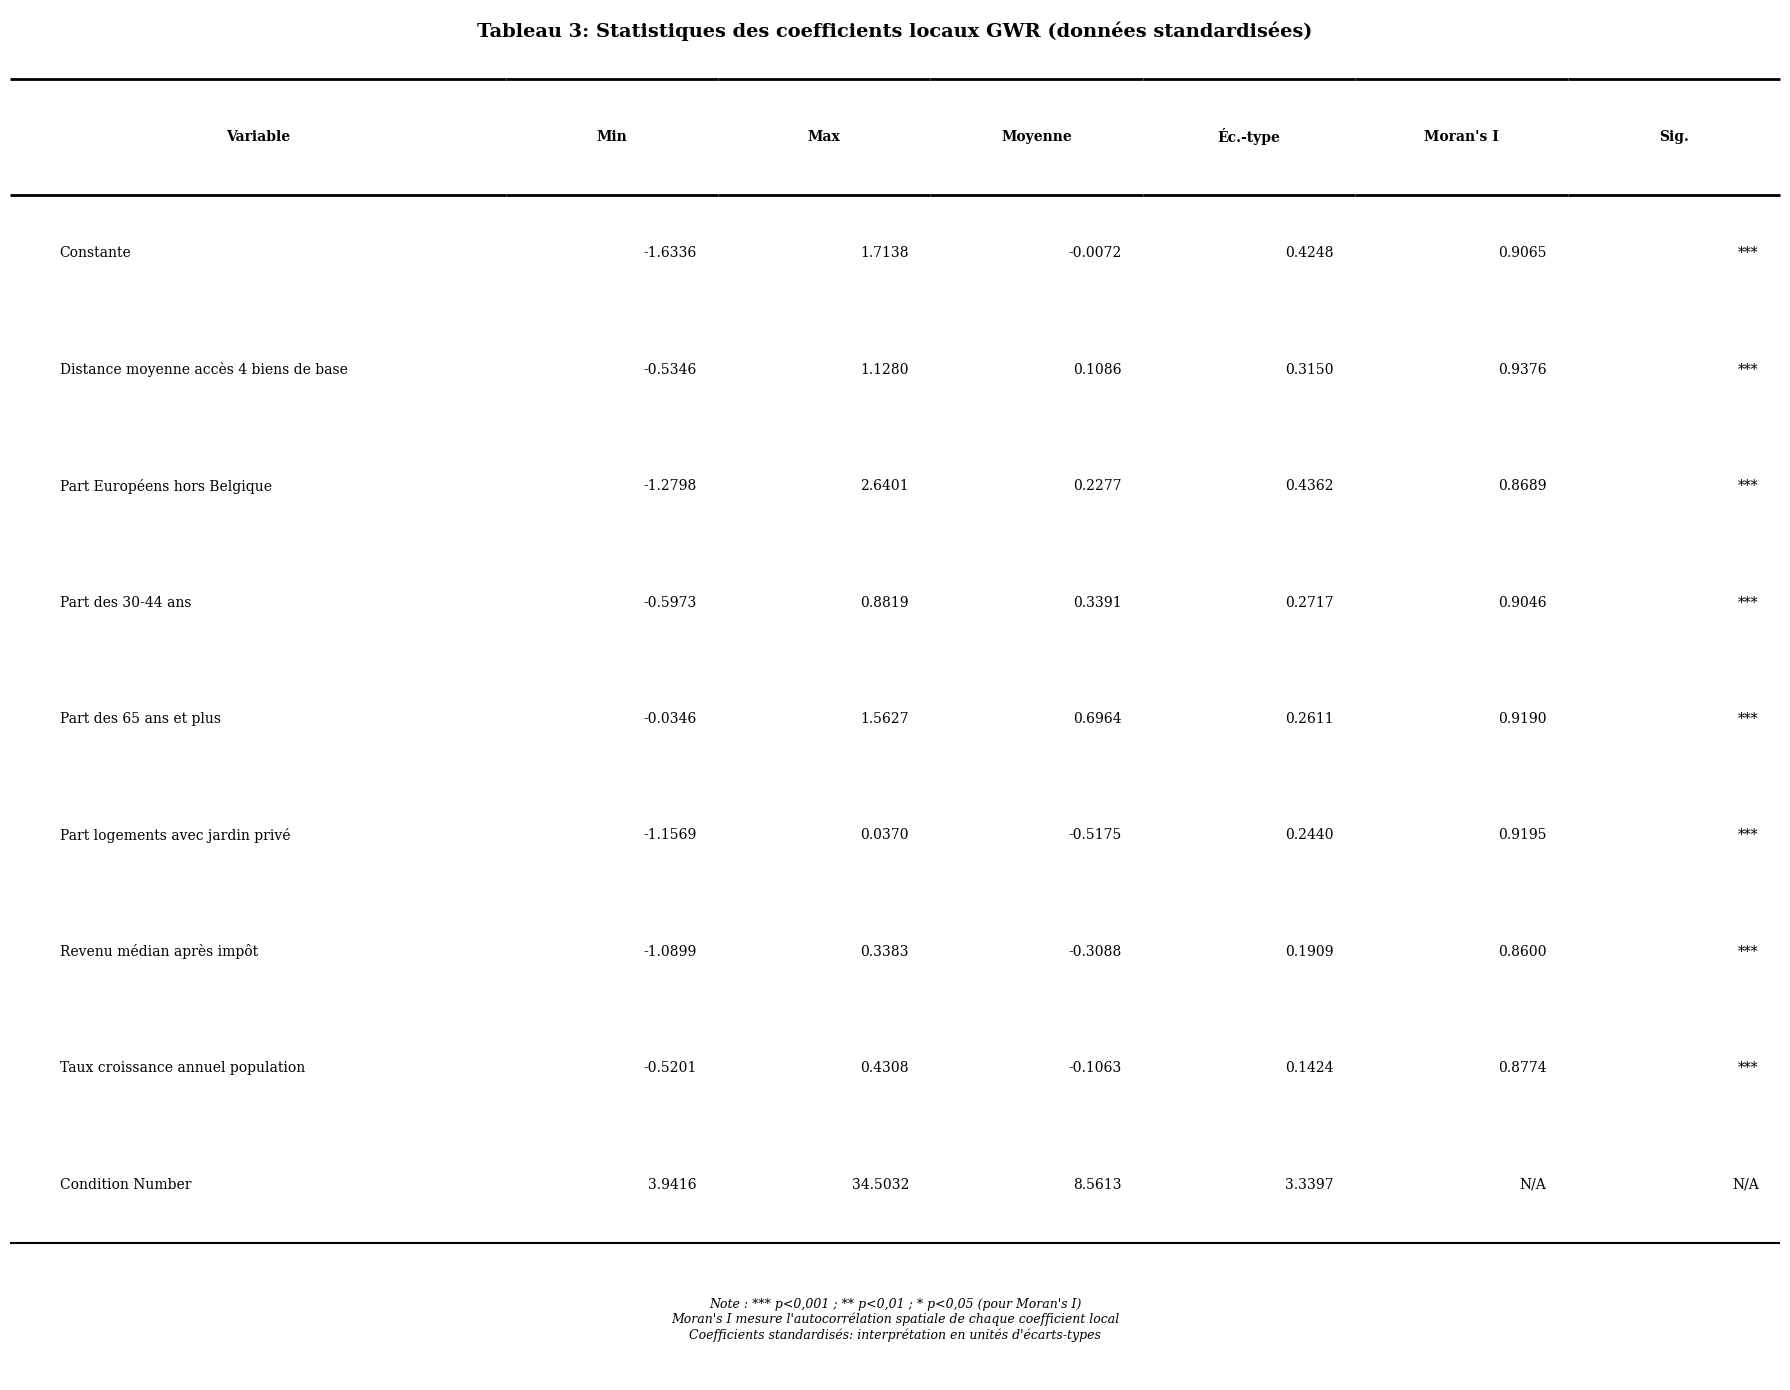

In [46]:
# Créer une version PNG formatée de la table GWR pour publication

var_names_fr_gwr = {
    'Constante': 'Constante',
    'Densite De Bureaux': 'Densité de bureaux',
    'Densite Des Menages Prives': 'Densité des ménages privés',
    'Distance Moyenne Dacces Aux 4 Biens De Base': 'Distance moyenne accès 4 biens de base',
    'Part De La Population A Proximite Dun Arret De Transport En Commun 3 Modes Confondus': 'Part pop. à prox. transports en commun',
    'Part De La Population A Proximite Dun Espace Vert Accessible Au Public': 'Part pop. à prox. spaces verts',
    'Part De La Voirie Dediee Au Trottoir': 'Part voirie dédiée au trottoir',
    'Part De Leurope Des 14 Hors Belgique': 'Part Européens hors Belgique',
    'Part Des 30 44 Ans Dans La Population Totale': 'Part des 30-44 ans',
    'Part Des 65 Ans Et Plus Dans La Population Totale': 'Part des 65 ans et plus',
    'Part Des Logements Ayant Acces A Un Jardin Prive': 'Part logements avec jardin privé',
    'Revenu Equivalent Median Des Habitants Apres Impot': 'Revenu médian après impôt',
    'Taux De Croissance Annuel Moyen De La Population': 'Taux croissance annuel population',
    'Taux De Vegetalisation': 'Taux de végétalisation',
    '--- Condition Number ---': 'Condition Number'
}

# Construire le dataframe ligne par ligne (même logique que OLS)
results_data = []
for _, row in gwr_stats_df.iterrows():
    var_name = row['Variable']
    var_fr = var_names_fr_gwr.get(var_name, var_name)
    
    # Significativité Moran's I
    if not np.isnan(row['Moran p-value']):
        if row['Moran p-value'] < 0.001:
            sig = '***'
        elif row['Moran p-value'] < 0.01:
            sig = '**'
        elif row['Moran p-value'] < 0.05:
            sig = '*'
        else:
            sig = ''
    else:
        sig = 'N/A'

    results_data.append({
        'Variable': var_fr,
        'Min': f"{row['Min']:.4f}" if not np.isnan(row['Min']) else 'N/A',
        'Max': f"{row['Max']:.4f}" if not np.isnan(row['Max']) else 'N/A',
        'Moyenne': f"{row['Mean']:.4f}" if not np.isnan(row['Mean']) else 'N/A',
        'Éc.-type': f"{row['Std']:.4f}" if not np.isnan(row['Std']) else 'N/A',
        "Moran's I": f"{row['Moran\'s I']:.4f}" if not np.isnan(row['Moran\'s I']) else 'N/A',
        'Sig.': sig
    })

results_df = pd.DataFrame(results_data)

# Créer la figure
fig = plt.figure(figsize=(18, 14))
ax = fig.add_subplot(111)
ax.axis('off')

# Largeurs de colonnes dynamiques
n_cols = len(results_df.columns)
first_col_width = 0.28
other_col_width = (1.0 - first_col_width) / (n_cols - 1)
colWidths = [first_col_width] + [other_col_width] * (n_cols - 1)

table = ax.table(cellText=results_df.values,
                colLabels=results_df.columns,
                cellLoc='left',
                loc='center',
                colWidths=colWidths,
                bbox=[0, 0.1, 1, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 3.5)

# Style des cellules
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

# Style header
for i in range(len(results_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', family='serif', size=10, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

# Style data rows
for i in range(1, len(results_df) + 1):
    for j in range(len(results_df.columns)):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=10, va='center')

        if j == 0:
            cell.set_text_props(ha='left', family='serif', size=10, va='center')
        else:
            cell.set_text_props(ha='right', family='serif', size=10, va='center')
            cell._loc = 'right'

        cell.visible_edges = ''

# Ligne de séparation avant Condition Number
cn_row = len(results_df)
for i in range(len(results_df.columns)):
    cell = table[(cn_row, i)]
    cell.visible_edges = 'T'
    cell.set_linewidth(1.5)

# Bottom border
for i in range(len(results_df.columns)):
    cell = table[(len(results_df), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)

# Titre
fig.text(0.5, 0.97, 'Tableau 3: Statistiques des coefficients locaux GWR (données standardisées)',
         ha='center', fontsize=14, fontweight='bold', family='serif')

# Note
note_text = '''Note : *** p<0,001 ; ** p<0,01 ; * p<0,05 (pour Moran\'s I)
Moran\'s I mesure l\'autocorrélation spatiale de chaque coefficient local
Coefficients standardisés: interprétation en unités d\'écarts-types'''

fig.text(0.5, 0.04, note_text, ha='center', fontsize=9, style='italic', family='serif')

plt.tight_layout()
plt.savefig('tableau_GWR_statistiques.png', dpi=300, bbox_inches='tight', facecolor='white')

print('✓ Table GWR formatée sauvegardée: tableau_GWR_statistiques.png')

✓ Saved local R² map
✓ Saved coefficient maps
✓ Saved results to gwr_results.geojson


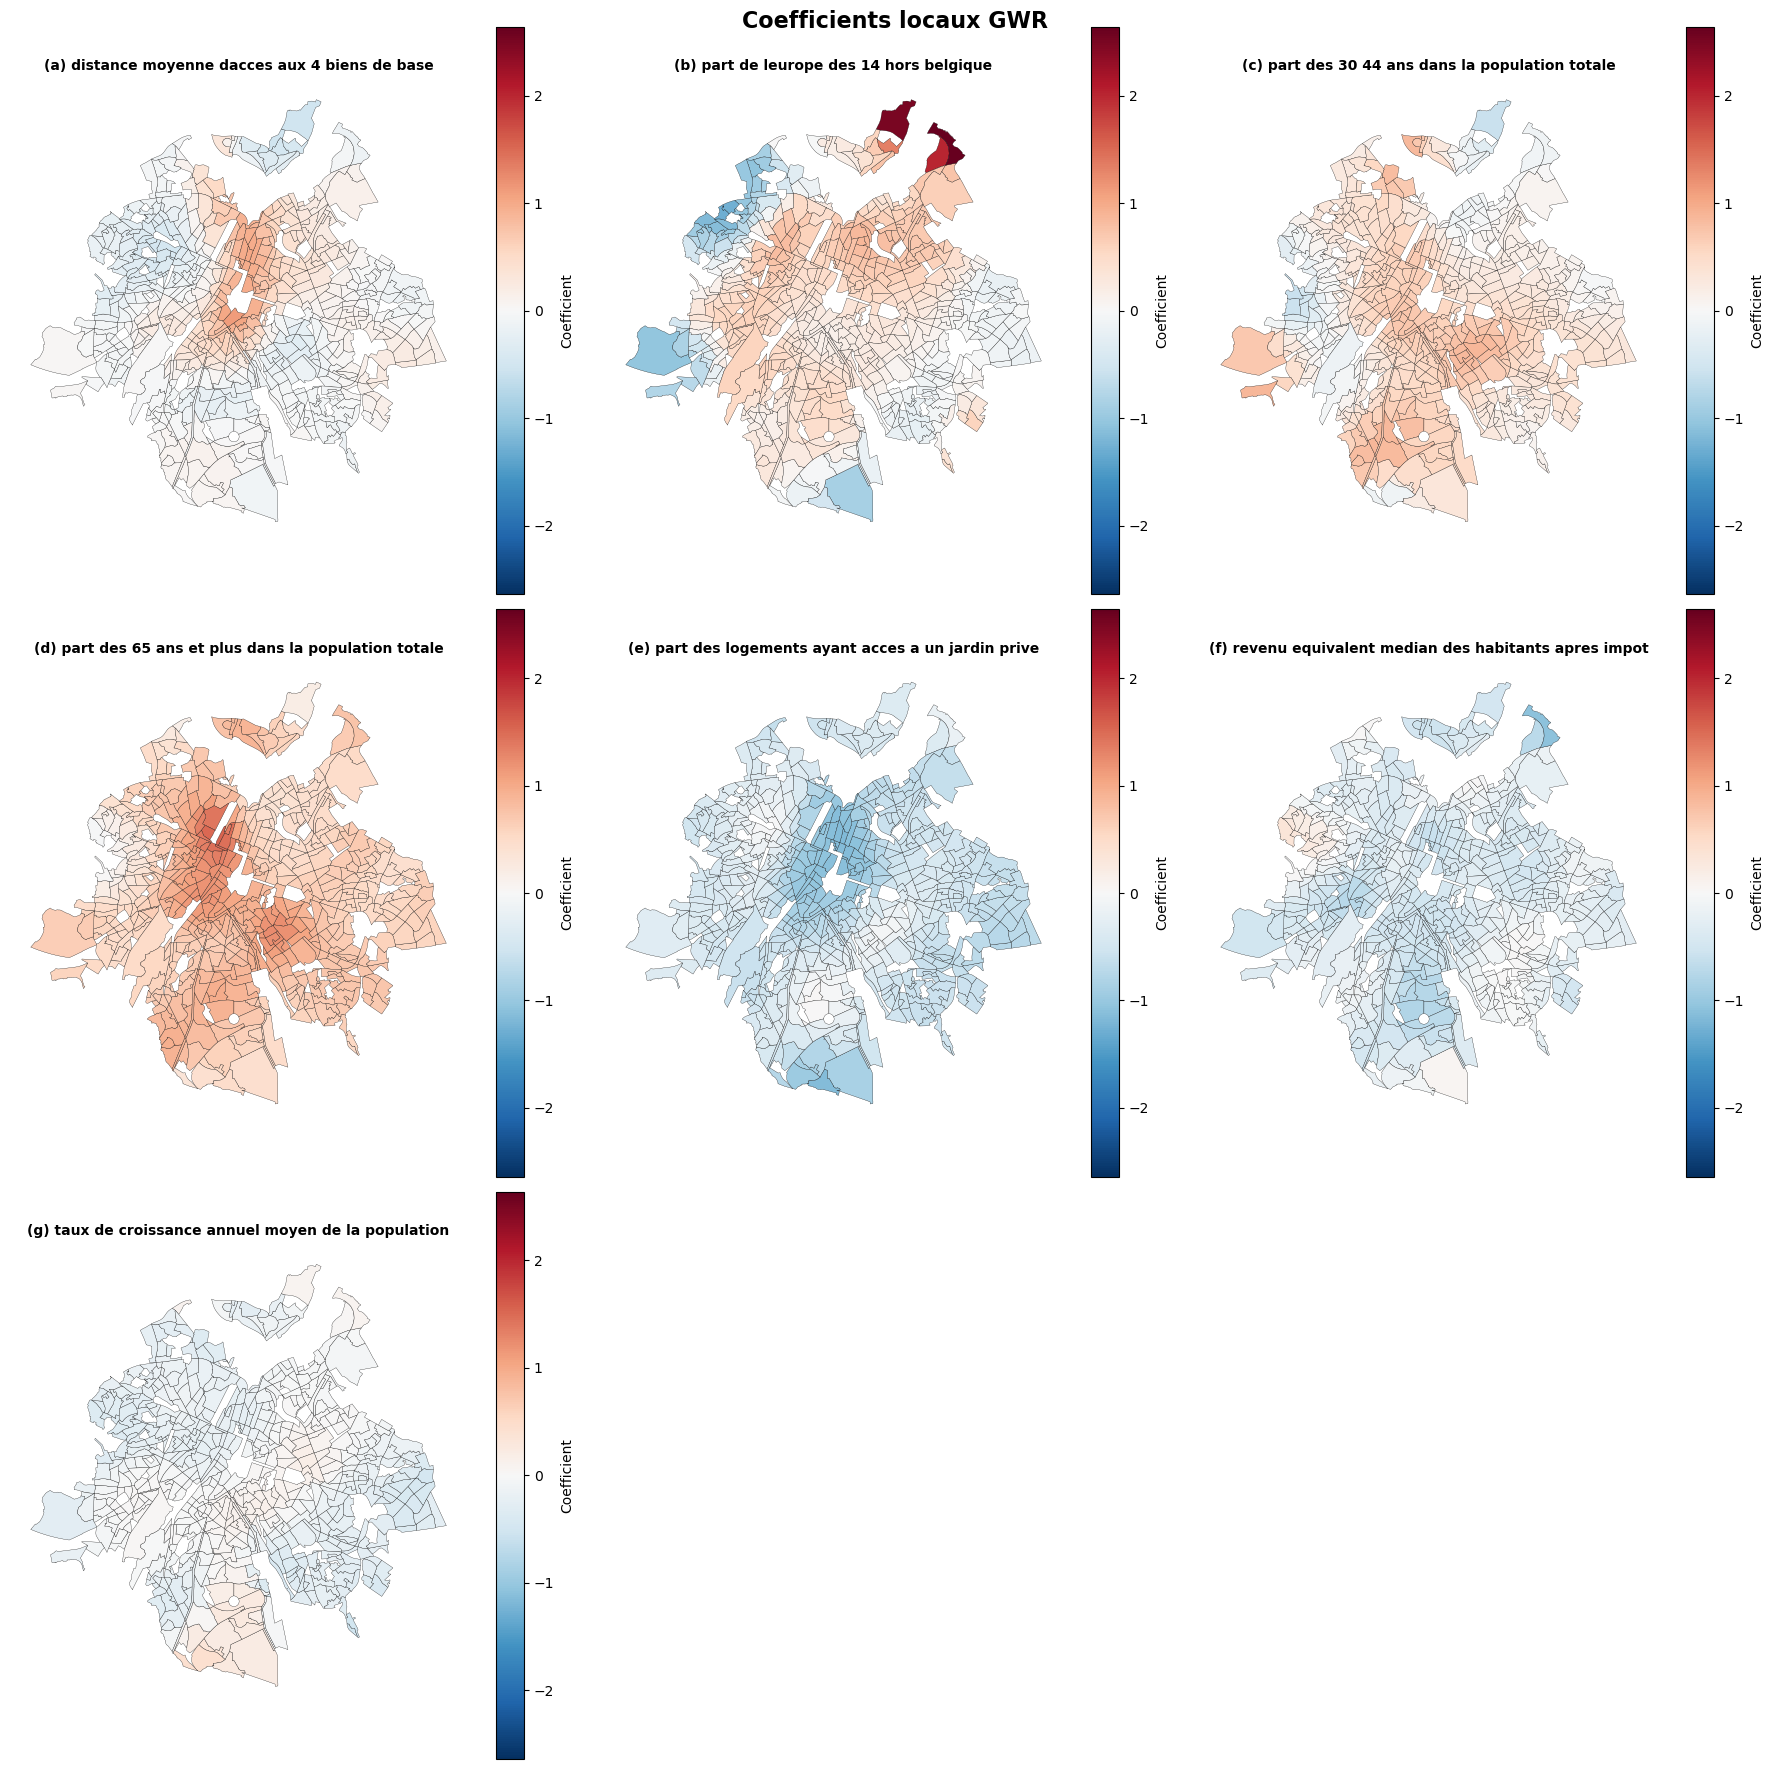

In [47]:
import string

# Create visualizations
# Map 1: Local R²
fig, ax = plt.subplots(figsize=(12, 10))
gdf_gwr.plot(column='local_r2', ax=ax, cmap='RdYlGn', edgecolor='black', 
             linewidth=0.2, legend=True, legend_kwds={'label': 'R² local'})
ax.set_title('Ajustement du modèle GWR (R² local)', fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('gwr_local_r2.png', dpi=150, bbox_inches='tight')
plt.close()
print('✓ Saved local R² map')

# Map 2: Local coefficients grid
n_cols = 3
n_rows = (len(indep_vars) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
axes = axes.flatten()

letters = list(string.ascii_lowercase)

# Échelle commune pour toutes les cartes
global_abs_max = max(
    max(abs(gdf_gwr[f'coef_{var}'].min()), abs(gdf_gwr[f'coef_{var}'].max()))
    for var in indep_vars
)

for idx, var in enumerate(indep_vars):
    ax = axes[idx]
    col = f'coef_{var}'
    
    gdf_gwr.plot(column=col, ax=ax, cmap='RdBu_r', edgecolor='black',
                 linewidth=0.2, legend=True, 
                 vmin=-global_abs_max, vmax=global_abs_max,
                 legend_kwds={'label': 'Coefficient'})
    
    var_label = var.replace('_', ' ')
    ax.set_title(f'({letters[idx]}) {var_label}', fontsize=10, fontweight='bold')
    ax.axis('off')

for idx in range(len(indep_vars), len(axes)):
    axes[idx].axis('off')

plt.suptitle('Coefficients locaux GWR', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('gwr_local_coefficients.png', dpi=150, bbox_inches='tight')

print('✓ Saved coefficient maps')

# Save results
gdf_gwr.to_file('gwr_results.geojson', driver='GeoJSON')
print('✓ Saved results to gwr_results.geojson')

## 8. Multicollinearity Diagnosis and Variable Selection

High Condition Number Analysis (CN > 15)
Total observations: 613
High CN areas: 23 (3.8%)
CN range in high areas: 15.25 - 34.50


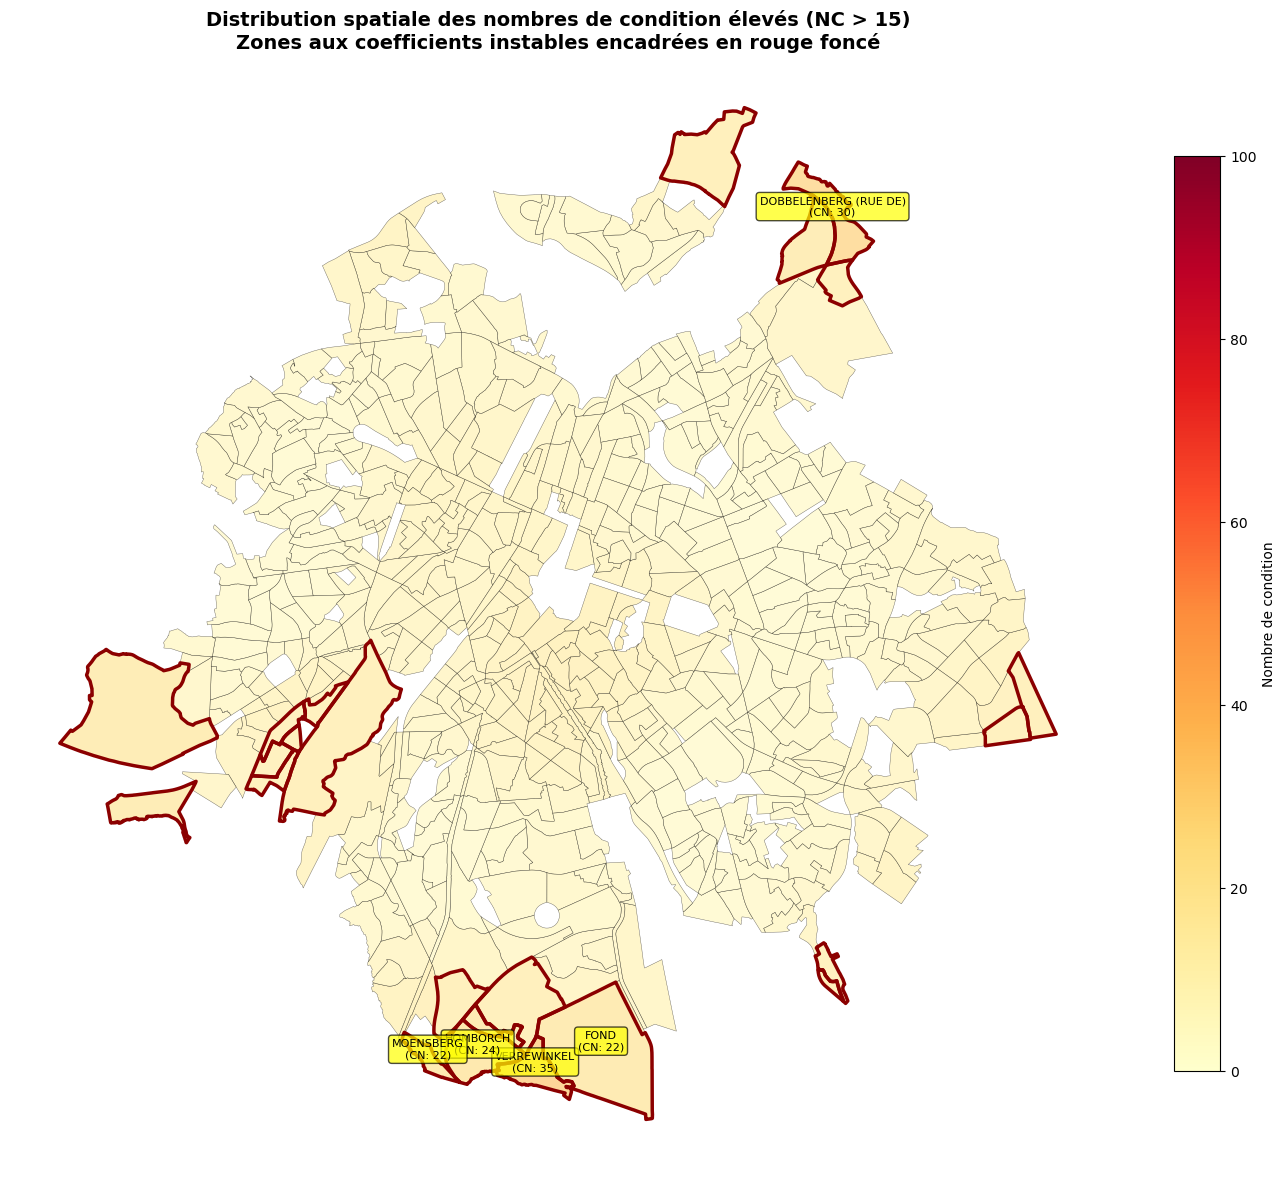


✓ Spatial map saved to high_cn_areas_map.png (23 areas highlighted)

Top 10 areas with highest Condition Numbers:
--------------------------------------------------------------------------------
  ID                  Name  Condition Number  Local R²
3079           VERREWINKEL         34.503243  0.947644
3064 DOBBELENBERG (RUE DE)         30.348664  0.982140
3078              HOMBORCH         24.146048  0.924566
3040             MOENSBERG         21.918932  0.917940
3080                  FOND         21.780743  0.974994
3555              ENGELAND         20.869980  0.900118
3207           ZONE RURALE         20.171008  0.923272
3245        HOPITAL U.L.B.         19.533092  0.976023
3059      SAINTE-ELISABETH         19.321636  0.968097
3324   DREVE DES EQUIPAGES         17.417250  0.792054

✓ High CN areas saved to high_cn_areas.csv


In [48]:
# 6.1 Identify and Map High Condition Number Areas

cn_threshold = 15
high_cn_areas = gdf_gwr[gdf_gwr['condition_number'] > cn_threshold].copy()

print(f'High Condition Number Analysis (CN > {cn_threshold})')
print('='*80)
print(f'Total observations: {len(gdf_gwr)}')
print(f'High CN areas: {len(high_cn_areas)} ({100*len(high_cn_areas)/len(gdf_gwr):.1f}%)')
print(f'CN range in high areas: {high_cn_areas["condition_number"].min():.2f} - {high_cn_areas["condition_number"].max():.2f}')
print('='*80)

# Create map of high CN areas
fig, ax = plt.subplots(figsize=(14, 12))

# Plot all areas with CN as background
gdf_gwr.plot(column='condition_number', ax=ax, cmap='YlOrRd', 
            edgecolor='black', linewidth=0.3, alpha=0.6,
            legend=True, legend_kwds={'label': 'Nombre de condition', 'shrink': 0.8},
            vmin=0, vmax=100)

# Highlight high CN areas
high_cn_areas.plot(ax=ax, edgecolor='darkred', facecolor='none', 
                   linewidth=2.5, alpha=1)

# Add labels for extreme CN areas
top_cn = high_cn_areas.nlargest(5, 'condition_number')
for idx, row in top_cn.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(
        f"{row['name']}\n(CN: {row['condition_number']:.0f})",
        xy=(centroid.x, centroid.y),
        fontsize=8,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7),
        ha='center'
    )

ax.set_title(f'Distribution spatiale des nombres de condition élevés (NC > {cn_threshold})\nZones aux coefficients instables encadrées en rouge foncé', 
            fontsize=14, fontweight='bold')
ax.axis('off')

plt.tight_layout()
plt.savefig('high_cn_areas_map.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n✓ Spatial map saved to high_cn_areas_map.png ({len(high_cn_areas)} areas highlighted)')

# Show top 10 areas with highest CN
if len(high_cn_areas) > 0:
    print(f'\nTop 10 areas with highest Condition Numbers:')
    print('-'*80)
    top_10_cn = high_cn_areas.nlargest(10, 'condition_number')[['id', 'name', 'condition_number', 'local_r2']]
    top_10_cn.columns = ['ID', 'Name', 'Condition Number', 'Local R²']
    print(top_10_cn.to_string(index=False))
    
    # Save to CSV
    high_cn_areas[['id', 'name', 'condition_number', 'local_r2']].to_csv('high_cn_areas.csv', index=False)
    print(f'\n✓ High CN areas saved to high_cn_areas.csv')


## 9. Significativité locale des coefficients GWR et cartographie masquée

ANALYSE DE SIGNIFICATIVITÉ LOCALE DES COEFFICIENTS GWR AVEC CORRECTION FDR

[Étape 1/5] Calcul des t-values et p-values locales...
  Calcul des statistiques locales pour 613 observations et 7 variables...
    10% complété...
    20% complété...
    30% complété...
    40% complété...
    50% complété...
    60% complété...
    70% complété...
    80% complété...
    90% complété...
    100% complété...
✓ Statistiques locales calculées

[Étape 2/5] Application de la correction FDR (Benjamini-Hochberg)...
✓ Correction FDR appliquée pour 7 variables

[Étape 3/5] Construction du masque combiné (non-significatif ou CN > 30)...
✓ Masque combiné construit
  Seuil CN: 30
  Quartiers avec CN > 30: 2 (0.3%)

[Étape 4/5] Création des cartes choroplèthes avec masquage...
  ✓ Carte sauvegardée: gwr_masked_maps/coef_distance_moyenne_dacces_aux_4_biens_de_base_masked.png
  ✓ Carte sauvegardée: gwr_masked_maps/coef_part_de_leurope_des_14_hors_belgique_masked.png
  ✓ Carte sauvegardée: gwr_masked_maps/

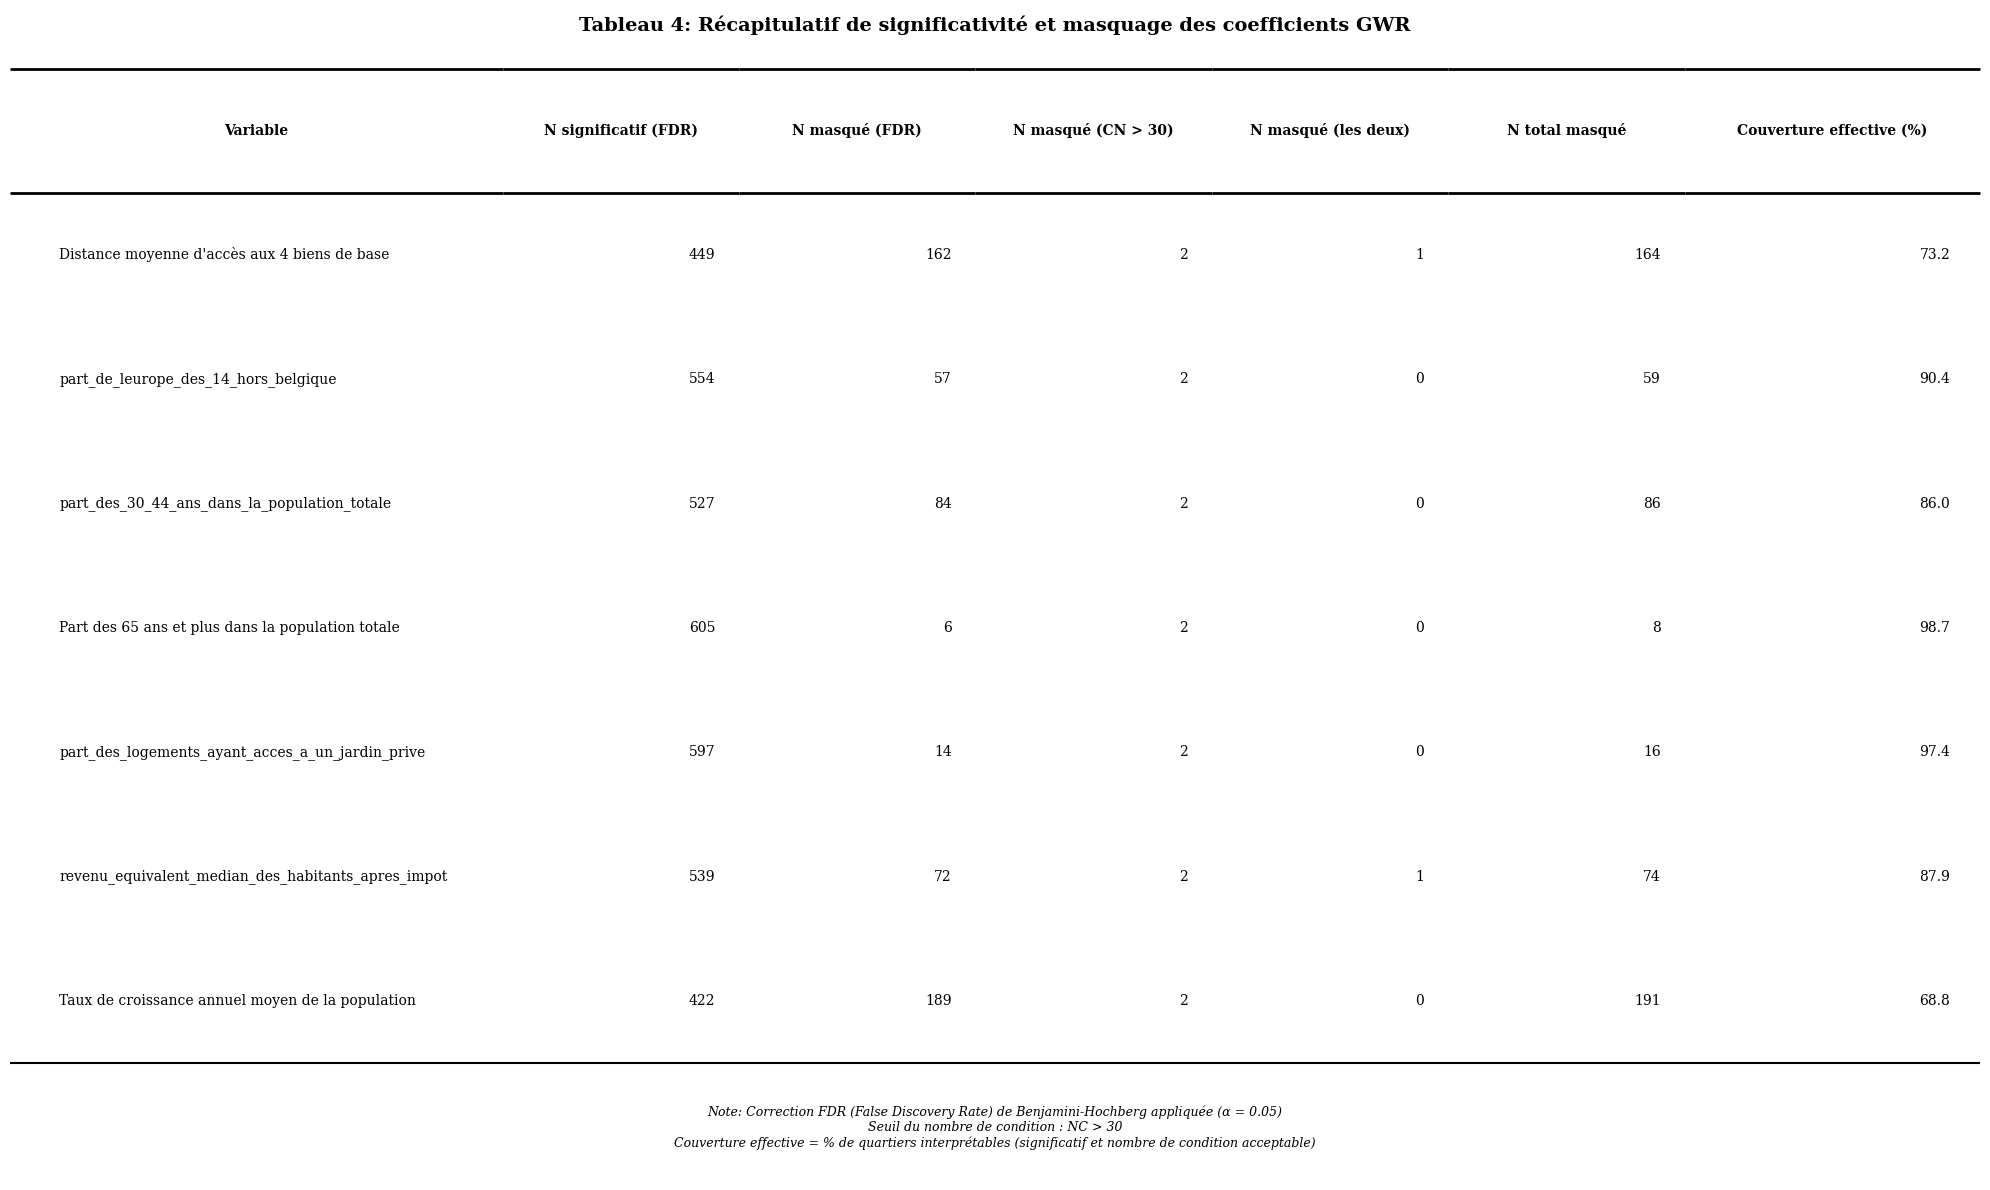

In [49]:
# ============================================================================
# SECTION 9: Significativité locale des coefficients GWR et cartographie masquée
# ============================================================================

from scipy import stats
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings('ignore')

print('='*80)
print('ANALYSE DE SIGNIFICATIVITÉ LOCALE DES COEFFICIENTS GWR AVEC CORRECTION FDR')
print('='*80)

# ============================================================================
# ÉTAPE 1: Récupérer/Calculer les t-values et p-values locales
# ============================================================================

print('\n[Étape 1/5] Calcul des t-values et p-values locales...')

# Préparer les données
X = regression_data_scaled[indep_vars].values
y = regression_data_scaled[dep_var].values
coords = np.column_stack([gdf_gwr.geometry.centroid.x, gdf_gwr.geometry.centroid.y])
n_obs = len(gdf_gwr)
n_vars = len(indep_vars)

# Utiliser la même bandwidth que pour le modèle GWR
bandwidth = 5000

# Calculer les distances
from scipy.spatial.distance import cdist
distances = cdist(coords, coords, metric='euclidean')

# Initialiser les matrices pour stocker les résultats
local_std_errors = np.zeros((n_obs, n_vars))
local_tvalues = np.zeros((n_obs, n_vars))
local_pvalues = np.zeros((n_obs, n_vars))

print(f'  Calcul des statistiques locales pour {n_obs} observations et {n_vars} variables...')

# Pour chaque observation, calculer les erreurs standard locales
for i in range(n_obs):
    # Calculer les poids (noyau Gaussien)
    weights = np.exp(-(distances[i, :] / bandwidth) ** 2)
    
    try:
        # Ajuster le modèle local pondéré
        from sklearn.linear_model import LinearRegression
        model_local = LinearRegression()
        model_local.fit(X, y, sample_weight=weights)
        
        # Prédictions locales
        y_pred = model_local.predict(X)
        
        # Résidus pondérés
        residuals = y - y_pred
        weighted_residuals = weights * (residuals ** 2)
        
        # Erreur standard des résidus
        n_effective = np.sum(weights > 0)
        if n_effective > n_vars + 1:
            sigma2 = np.sum(weighted_residuals) / (n_effective - n_vars - 1)
            
            # Matrice X pondérée
            W_sqrt = np.sqrt(weights).reshape(-1, 1)
            X_weighted = X * W_sqrt
            
            # Calculer (X'WX)^-1 pour les erreurs standard
            try:
                XtWX = X_weighted.T @ X_weighted
                XtWX_inv = np.linalg.inv(XtWX)
                
                # Erreurs standard des coefficients
                var_coef = sigma2 * np.diag(XtWX_inv)
                std_errors = np.sqrt(np.abs(var_coef))
                
                # Récupérer les coefficients locaux depuis gdf_gwr
                coefs = np.array([gdf_gwr.loc[i, f'coef_{var}'] for var in indep_vars])
                
                # Calculer t-values et p-values
                t_vals = coefs / (std_errors + 1e-10)  # Éviter division par zéro
                p_vals = 2 * (1 - stats.t.cdf(np.abs(t_vals), df=n_effective - n_vars - 1))
                
                # Stocker les résultats
                local_std_errors[i, :] = std_errors
                local_tvalues[i, :] = t_vals
                local_pvalues[i, :] = p_vals
            except:
                # En cas d'erreur (matrice singulière), utiliser NaN
                local_std_errors[i, :] = np.nan
                local_tvalues[i, :] = np.nan
                local_pvalues[i, :] = np.nan
        else:
            local_std_errors[i, :] = np.nan
            local_tvalues[i, :] = np.nan
            local_pvalues[i, :] = np.nan
    except:
        local_std_errors[i, :] = np.nan
        local_tvalues[i, :] = np.nan
        local_pvalues[i, :] = np.nan
    
    # Progression
    if (i + 1) % max(1, n_obs // 10) == 0:
        print(f'    {(i + 1) / n_obs * 100:.0f}% complété...')

print(f'✓ Statistiques locales calculées')

# ============================================================================
# ÉTAPE 2: Appliquer le False Discovery Rate (FDR)
# ============================================================================

print('\n[Étape 2/5] Application de la correction FDR (Benjamini-Hochberg)...')

# Initialiser la matrice de significativité (booléenne)
significant_fdr = np.zeros((n_obs, n_vars), dtype=bool)

# Pour chaque variable, appliquer la correction FDR
fdr_stats = []
for j, var in enumerate(indep_vars):
    pvals = local_pvalues[:, j]
    
    # Retirer les NaN pour la correction FDR
    valid_mask = ~np.isnan(pvals)
    valid_pvals = pvals[valid_mask]
    
    if len(valid_pvals) > 0:
        # Appliquer la correction FDR de Benjamini-Hochberg
        reject, pvals_corrected, _, _ = multipletests(valid_pvals, method='fdr_bh', alpha=0.05)
        
        # Remplir la matrice de significativité
        significant_fdr[valid_mask, j] = reject
        
        # Stocker les stats
        n_significant = np.sum(reject)
        pct_significant = 100 * n_significant / len(valid_pvals)
        fdr_stats.append({
            'Variable': var,
            'N_valid': len(valid_pvals),
            'N_significant': n_significant,
            'Pct_significant': pct_significant
        })
    else:
        fdr_stats.append({
            'Variable': var,
            'N_valid': 0,
            'N_significant': 0,
            'Pct_significant': 0
        })

print(f'✓ Correction FDR appliquée pour {n_vars} variables')

# ============================================================================
# ÉTAPE 3: Construire le masque combiné (FDR + CN > 30)
# ============================================================================

print('\n[Étape 3/5] Construction du masque combiné (non-significatif ou CN > 30)...')

cn_threshold = 30
cn_values = gdf_gwr['condition_number'].values

# Initialiser le masque combiné
masked_combined = np.zeros((n_obs, n_vars), dtype=bool)

# Pour chaque variable
mask_stats = []
for j, var in enumerate(indep_vars):
    # Masquer si:
    # 1. Non significatif après FDR
    # 2. Condition number > 30
    mask_fdr = ~significant_fdr[:, j]  # Non significatif
    mask_cn = cn_values > cn_threshold  # CN élevé
    
    # Masque combiné
    masked_combined[:, j] = mask_fdr | mask_cn
    
    # Statistiques
    n_masked_fdr = np.sum(mask_fdr & ~mask_cn)
    n_masked_cn = np.sum(mask_cn)
    n_masked_both = np.sum(mask_fdr & mask_cn)
    n_total_masked = np.sum(masked_combined[:, j])
    n_valid = n_obs - n_total_masked
    pct_valid = 100 * n_valid / n_obs
    
    mask_stats.append({
        'Variable': var,
        'N_masked_FDR': n_masked_fdr,
        'N_masked_CN': n_masked_cn,
        'N_masked_both': n_masked_both,
        'N_total_masked': n_total_masked,
        'N_valid': n_valid,
        'Pct_valid': pct_valid
    })

print(f'✓ Masque combiné construit')
print(f'  Seuil CN: {cn_threshold}')
print(f'  Quartiers avec CN > {cn_threshold}: {np.sum(cn_values > cn_threshold)} ({100*np.sum(cn_values > cn_threshold)/n_obs:.1f}%)')

# ============================================================================
# ÉTAPE 4: Cartographier les coefficients masqués
# ============================================================================

print('\n[Étape 4/5] Création des cartes choroplèthes avec masquage...')

# Créer un répertoire pour les cartes
import os
os.makedirs('gwr_masked_maps', exist_ok=True)

# Noms français des variables
var_names_fr = {
    'densite_du_bati': 'Densité du bâti',
    'densite_de_bureaux': 'Densité de bureaux',
    'densite_des_menages_prives': 'Densité des ménages privés',
    'distance_moyenne_dacces_aux_4_biens_de_base': 'Distance moyenne d\'accès aux 4 biens de base',
    'part_de_la_population_a_proximite_dun_arret_de_transport_bbcommun_3_modes_confondus': 'Part de la population à proximité d\'un arrêt de transport en commun (3 modes confondus)',
    'part_de_la_population_a_proximite_dun_espace_vert_accessible_au_public': 'Part de la population à proximité d\'un espace vert accessible au public',
    'part_de_la_valise_dedoua_au_toutvout': 'Part de la valise d\'eau au tout-à-l\'égout',
    'part_du_louvrage_des_14_hors_biologique': 'Part du louvrage des 14 hors biologique',
    'part_des_30_45_ans_dans_la_population_totale': 'Part des 30-45 ans dans la population totale',
    'part_des_65_ans_et_plus_dans_la_population_totale': 'Part des 65 ans et plus dans la population totale',
    'part_des_logements_ayant_un_din_jardin_prive': 'Part des logements ayant un jardin privé',
    'revenu_equivalent_mediana_des_habitants_apres_impot': 'Revenu équivalent médian des habitants après impôt',
    'taux_de_croissance_annuel_moyen_de_la_population': 'Taux de croissance annuel moyen de la population',
    'taux_de_vegetalisation': 'Taux de végétalisation'
}

# Pour chaque variable, créer une carte
for j, var in enumerate(indep_vars):
    # Créer une copie du GeoDataFrame
    gdf_map = gdf_gwr.copy()
    
    # Récupérer les coefficients
    coef_col = f'coef_{var}'
    coefs = gdf_map[coef_col].values.copy()
    
    # Appliquer le masque (remplacer par NaN)
    coefs_masked = coefs.copy()
    coefs_masked[masked_combined[:, j]] = np.nan
    gdf_map['coef_masked'] = coefs_masked
    
    # Créer la carte
    fig, ax = plt.subplots(figsize=(14, 12))
    
    # Séparer les zones valides et masquées
    gdf_valid = gdf_map[~masked_combined[:, j]].copy()
    gdf_masked = gdf_map[masked_combined[:, j]].copy()
    
    # Tracer les zones masquées en gris
    if len(gdf_masked) > 0:
        gdf_masked.plot(ax=ax, color='lightgray', edgecolor='darkgray', 
                       linewidth=0.5, alpha=0.6, label='Masqué (non significatif ou CN > 30)')
    
    # Tracer les zones valides avec palette divergente
    if len(gdf_valid) > 0:
        # Déterminer les limites de la palette (symétriques autour de 0)
        vmin_val = gdf_valid['coef_masked'].min()
        vmax_val = gdf_valid['coef_masked'].max()
        vmax_abs = max(abs(vmin_val), abs(vmax_val))
        
        gdf_valid.plot(column='coef_masked', ax=ax, cmap='RdBu_r', 
                      edgecolor='black', linewidth=0.3,
                      vmin=-vmax_abs, vmax=vmax_abs,
                      legend=True, 
                      legend_kwds={'label': 'Coefficient standardisé', 
                                  'shrink': 0.8,
                                  'orientation': 'horizontal',
                                  'pad': 0.05})
    
    # Titre et annotations
    var_fr = var_names_fr.get(var, var)
    n_masked = np.sum(masked_combined[:, j])
    n_valid = n_obs - n_masked
    pct_masked = 100 * n_masked / n_obs
    
    ax.set_title(f'Coefficient GWR local: {var_fr}\\n' + 
                f'({n_valid} quartiers significatifs, {n_masked} masqués [{pct_masked:.1f}%])',
                fontsize=14, fontweight='bold', pad=20)
    
    ax.axis('off')
    
    # Note en bas
    note_text = f'''Note: Zones masquées (gris) = coefficient non significatif après correction FDR ou CN > {cn_threshold}
Coefficients standardisés (en unités d'écarts-types)'''
    fig.text(0.5, 0.02, note_text, ha='center', fontsize=9, style='italic', family='serif')
    
    plt.tight_layout()
    
    # Sauvegarder
    filename = f'gwr_masked_maps/coef_{var}_masked.png'
    plt.savefig(filename, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close()
    
    print(f'  ✓ Carte sauvegardée: {filename}')

print(f'✓ {n_vars} cartes sauvegardées dans le dossier gwr_masked_maps/')

# ============================================================================
# ÉTAPE 5: Tableau récapitulatif
# ============================================================================

print('\n[Étape 5/5] Création du tableau récapitulatif...')

# Créer le tableau synthétique
summary_data = []
for j, var in enumerate(indep_vars):
    var_fr = var_names_fr.get(var, var)
    stats = mask_stats[j]
    
    summary_data.append({
        'Variable': var_fr,
        'N significatif (FDR)': stats['N_valid'],
        'N masqué (FDR)': stats['N_masked_FDR'],
        'N masqué (CN > 30)': stats['N_masked_CN'],
        'N masqué (les deux)': stats['N_masked_both'],
        'N total masqué': stats['N_total_masked'],
        'Couverture effective (%)': f"{stats['Pct_valid']:.1f}"
    })

summary_df = pd.DataFrame(summary_data)

# Afficher le tableau
print('\\n' + '='*80)
print('TABLEAU RÉCAPITULATIF: Significativité et masquage des coefficients GWR')
print('='*80)
print(summary_df.to_string(index=False))
print('='*80)

# Sauvegarder en CSV
summary_df.to_csv('gwr_significance_summary.csv', index=False)
print('\\n✓ Tableau sauvegardé: gwr_significance_summary.csv')

# Créer une version PNG formatée du tableau
fig = plt.figure(figsize=(20, 12))
ax = fig.add_subplot(111)
ax.axis('off')

# Préparer les données pour affichage
display_df = summary_df.copy()

# Largeurs de colonnes personnalisées
colWidths = [0.25, 0.12, 0.12, 0.12, 0.12, 0.12, 0.15]

table = ax.table(cellText=display_df.values,
                colLabels=display_df.columns,
                cellLoc='left',
                loc='center',
                colWidths=colWidths,
                bbox=[0, 0.1, 1, 0.85])

# Style
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2.8)

# Style des cellules
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

# Style header
for i in range(len(display_df.columns)):
    cell = table[(0, i)]
    cell.set_text_props(weight='bold', family='serif', size=10, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

# Style data rows
for i in range(1, len(display_df) + 1):
    for j in range(len(display_df.columns)):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=10, va='center')
        
        if j == 0:  # Variable
            cell.set_text_props(ha='left', family='serif', size=10, va='center')
        else:  # Valeurs numériques
            cell.set_text_props(ha='right', family='serif', size=10, va='center')
            cell._loc = 'right'
        
        cell.visible_edges = ''

# Bottom border
for i in range(len(display_df.columns)):
    cell = table[(len(display_df), i)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)

# Titre
fig.text(0.5, 0.97, 'Tableau 4: Récapitulatif de significativité et masquage des coefficients GWR', 
         ha='center', fontsize=14, fontweight='bold', family='serif')

# Note
note_text = f'''Note: Correction FDR (False Discovery Rate) de Benjamini-Hochberg appliquée (α = 0.05)
Seuil du nombre de condition : NC > {cn_threshold}
Couverture effective = % de quartiers interprétables (significatif et nombre de condition acceptable)'''

fig.text(0.5, 0.04, note_text, ha='center', fontsize=9, style='italic', family='serif')

plt.tight_layout()
plt.savefig('tableau_GWR_significance_summary.png', dpi=300, bbox_inches='tight', facecolor='white')

print('✓ Tableau PNG sauvegardé: tableau_GWR_significance_summary.png')

# Statistiques globales
print('\\n' + '='*80)
print('STATISTIQUES GLOBALES')
print('='*80)
print(f'Nombre total de quartiers: {n_obs}')
print(f'Nombre de variables: {n_vars}')
print(f'Quartiers avec CN > {cn_threshold}: {np.sum(cn_values > cn_threshold)} ({100*np.sum(cn_values > cn_threshold)/n_obs:.1f}%)')
print(f'\\nCouverture effective moyenne: {summary_df["Couverture effective (%)"].astype(float).mean():.1f}%')
print('='*80)

Tableau 5: Synthèse GWR – coefficients locaux + couverture effective
                              Variable     Min     Max Moyenne Éc.-type Moran's I Sig. Moy. val. abs. Couv. eff. (%)
                             Constante -1.6336  1.7138 -0.0072   0.4248    0.9065  ***         0.2874            N/A
Distance moyenne accès 4 biens de base -0.5346  1.1280  0.1086   0.3150    0.9376  ***         0.2343           73.2
          Part Européens hors Belgique -1.2798  2.6401  0.2277   0.4362    0.8689  ***         0.3946           90.4
                    Part des 30-44 ans -0.5973  0.8819  0.3391   0.2717    0.9046  ***         0.3713           86.0
               Part des 65 ans et plus -0.0346  1.5627  0.6964   0.2611    0.9190  ***         0.6965           98.7
      Part logements avec jardin privé -1.1569  0.0370 -0.5175   0.2440    0.9195  ***         0.5177           97.4
             Revenu médian après impôt -1.0899  0.3383 -0.3088   0.1909    0.8600  ***         0.3206           

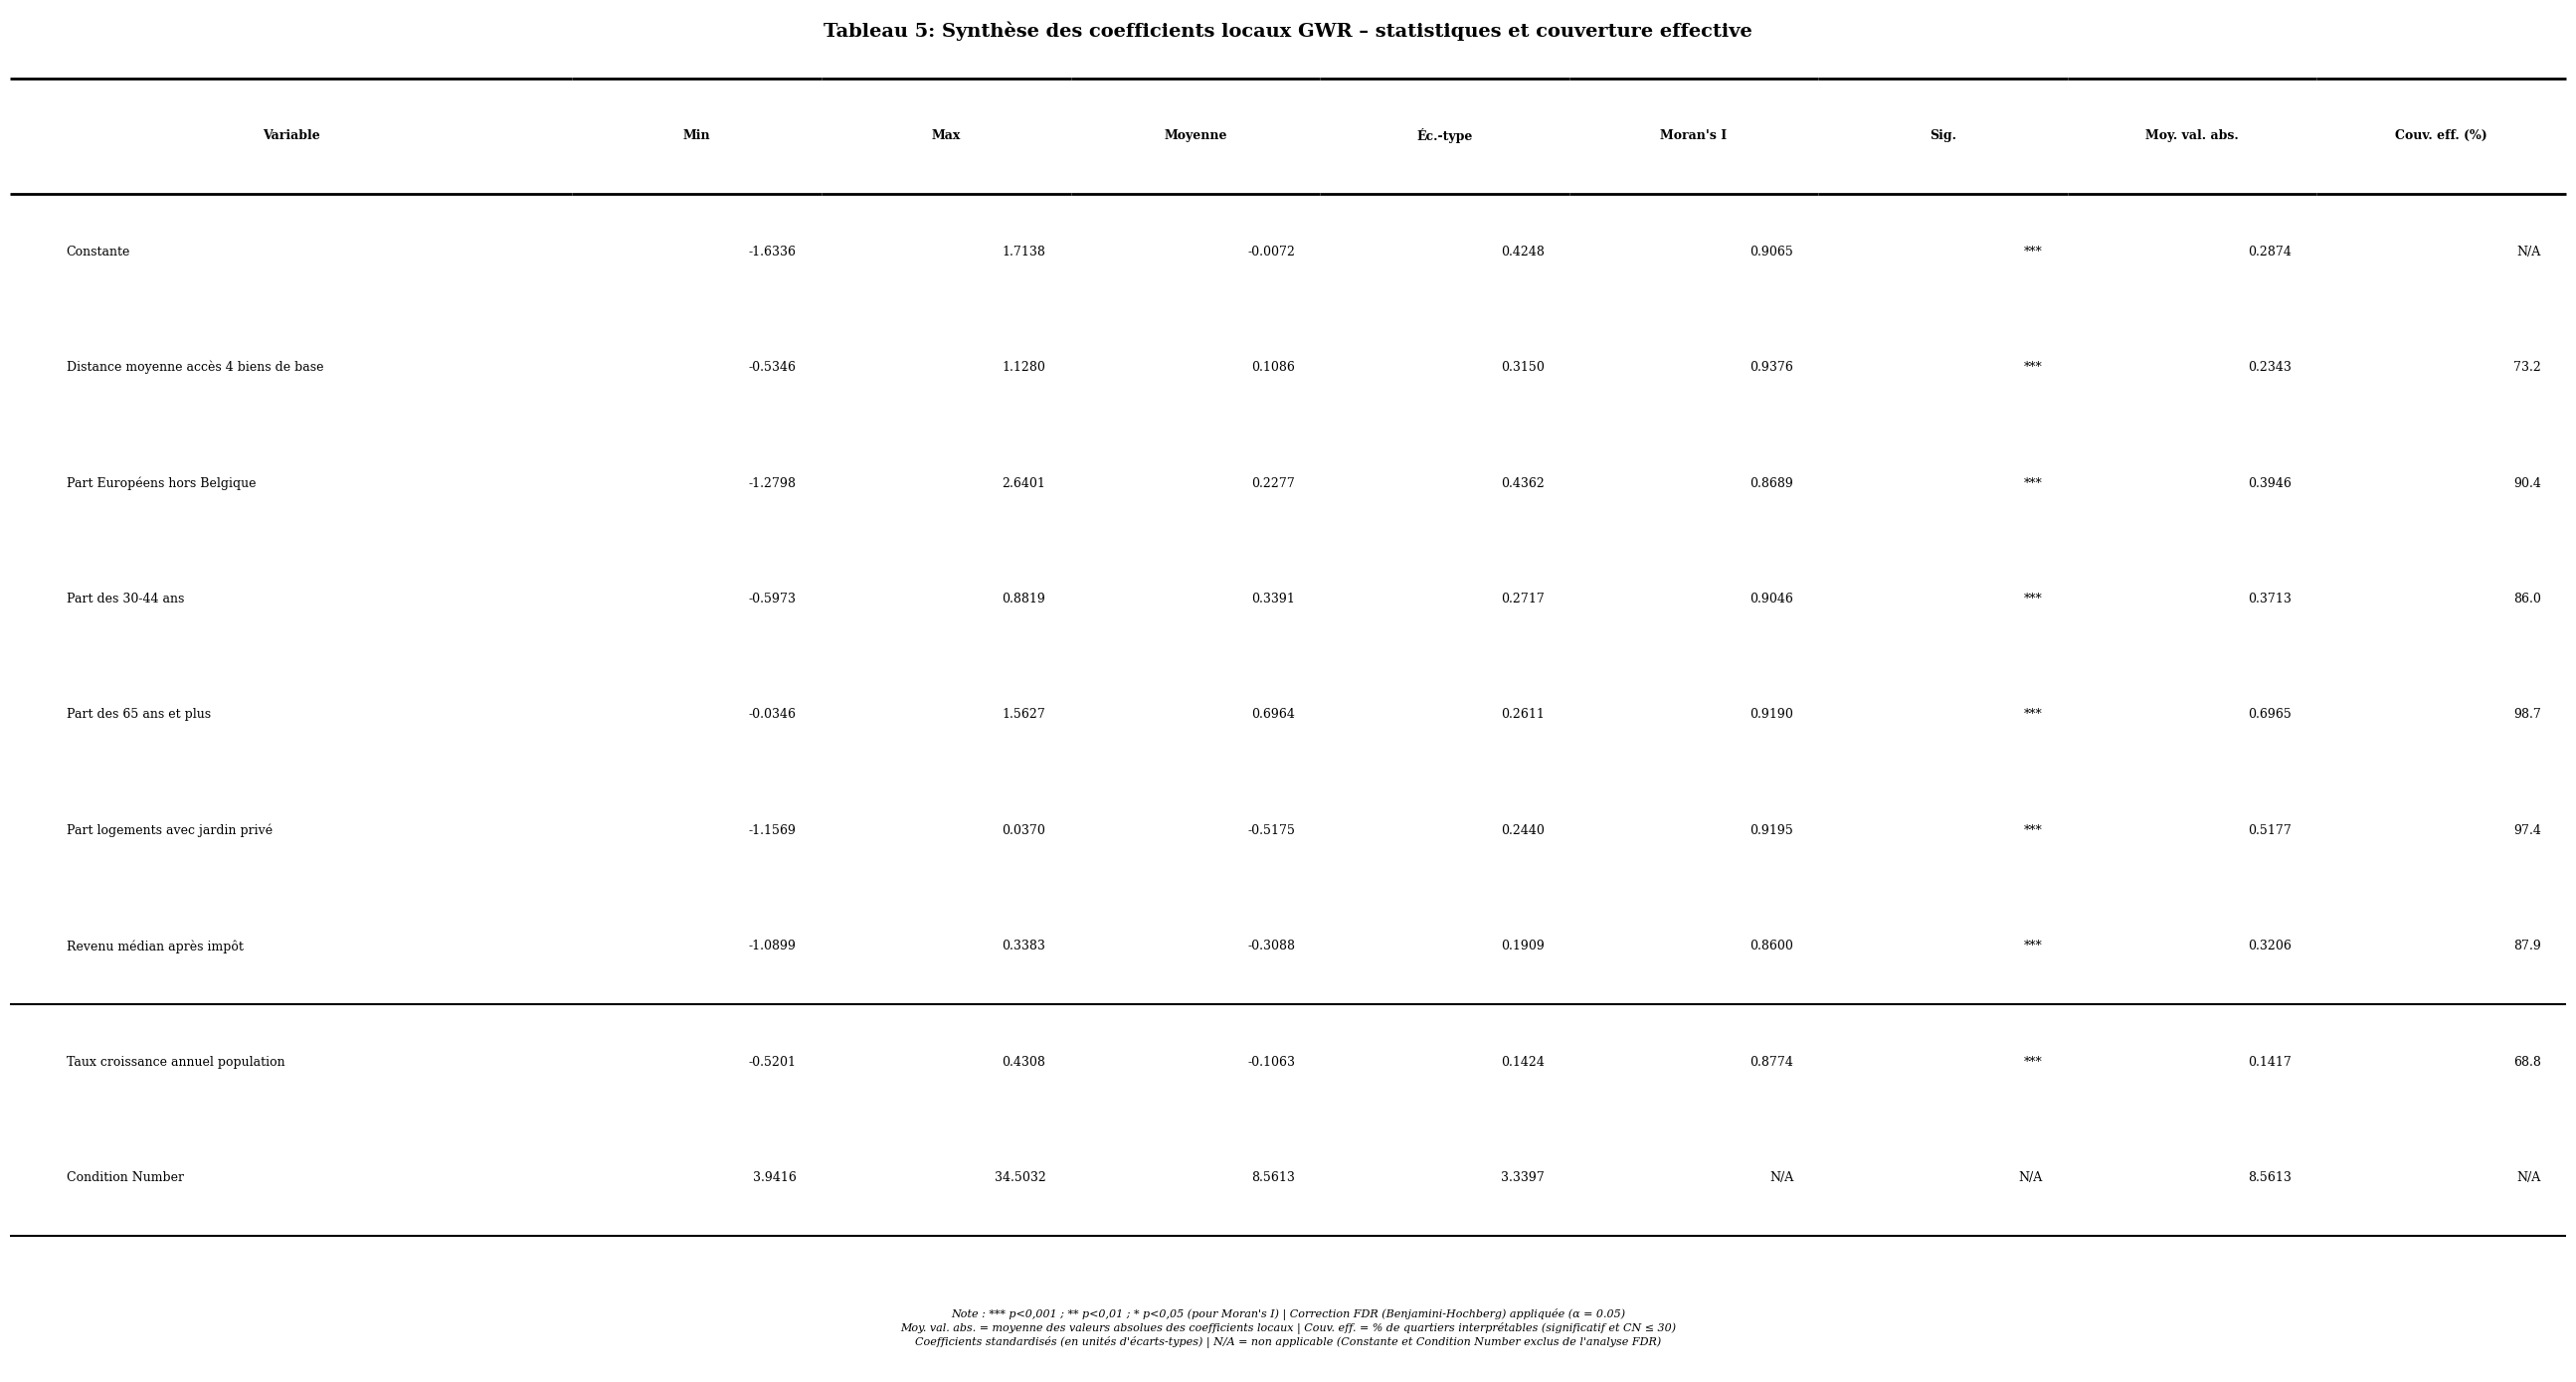

In [50]:
# ============================================================================
# TABLEAU 5: Synthèse des statistiques GWR + Couverture effective
# Reprend le Tableau 3 et ajoute la moyenne des valeurs absolues
# et la couverture effective du Tableau 4
# ============================================================================

# Lookup couverture effective depuis mask_stats (keyed by snake_case var name)
coverage_lookup = {mask_stats[j]['Variable']: mask_stats[j]['Pct_valid']
                   for j in range(len(mask_stats))}

# Construire le tableau ligne par ligne
tableau5_data = []

for i, (_, row) in enumerate(gwr_stats_df.iterrows()):
    var_name = row['Variable']
    # Nom français (via var_names_fr_gwr)
    var_fr = var_names_fr_gwr.get(var_name, var_name)

    # Identifier la colonne dans gdf_gwr et la variable originale
    if i == 0:  # Constante (intercept)
        col_name = 'intercept'
        var_orig = None
    elif i <= n_vars:  # Variables indépendantes
        var_orig = indep_vars[i - 1]
        col_name = f'coef_{var_orig}'
    else:  # Condition Number
        col_name = 'condition_number'
        var_orig = None

    # Moyenne des valeurs absolues
    if col_name in gdf_gwr.columns:
        coef_vals = gdf_gwr[col_name].values
        mean_abs_str = f'{np.nanmean(np.abs(coef_vals)):.4f}'
    else:
        mean_abs_str = 'N/A'

    # Couverture effective (uniquement pour les variables indépendantes)
    if var_orig is not None and var_orig in coverage_lookup:
        couv_str = f"{coverage_lookup[var_orig]:.1f}"
    else:
        couv_str = 'N/A'

    # Significativité Moran's I
    moran_p = row['Moran p-value']
    moran_i_val = row["Moran's I"]
    if not np.isnan(moran_p):
        if moran_p < 0.001:
            sig = '***'
        elif moran_p < 0.01:
            sig = '**'
        elif moran_p < 0.05:
            sig = '*'
        else:
            sig = ''
    else:
        sig = 'N/A'

    tableau5_data.append({
        'Variable': var_fr,
        'Min': f"{row['Min']:.4f}" if not np.isnan(row['Min']) else 'N/A',
        'Max': f"{row['Max']:.4f}" if not np.isnan(row['Max']) else 'N/A',
        'Moyenne': f"{row['Mean']:.4f}" if not np.isnan(row['Mean']) else 'N/A',
        'Éc.-type': f"{row['Std']:.4f}" if not np.isnan(row['Std']) else 'N/A',
        "Moran's I": f'{moran_i_val:.4f}' if not np.isnan(moran_i_val) else 'N/A',
        'Sig.': sig,
        'Moy. val. abs.': mean_abs_str,
        'Couv. eff. (%)': couv_str
    })

tableau5_df = pd.DataFrame(tableau5_data)

print('Tableau 5: Synthèse GWR – coefficients locaux + couverture effective')
print(tableau5_df.to_string(index=False))

tableau5_df.to_csv('tableau_GWR_synthese.csv', index=False)
print('\n✓ Tableau 5 sauvegardé: tableau_GWR_synthese.csv')

# ============================================================================
# Affichage formaté (style publication)
# ============================================================================

n_cols_t5 = len(tableau5_df.columns)
first_col_width = 0.22
other_col_width = (1.0 - first_col_width) / (n_cols_t5 - 1)
colWidths_t5 = [first_col_width] + [other_col_width] * (n_cols_t5 - 1)

fig = plt.figure(figsize=(26, 14))
ax = fig.add_subplot(111)
ax.axis('off')

table = ax.table(cellText=tableau5_df.values,
                 colLabels=tableau5_df.columns,
                 cellLoc='left',
                 loc='center',
                 colWidths=colWidths_t5,
                 bbox=[0, 0.1, 1, 0.85])

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 3.5)

# Style des cellules
for key, cell in table.get_celld().items():
    cell.set_linewidth(0)
    cell.set_edgecolor('black')
    cell.set_facecolor('white')
    cell.set_text_props(family='serif')

# Style header
for j in range(n_cols_t5):
    cell = table[(0, j)]
    cell.set_text_props(weight='bold', family='serif', size=9, va='center')
    cell.set_facecolor('white')
    cell.visible_edges = 'TB'
    cell.set_linewidth(2.0)

# Style data rows
for i in range(1, len(tableau5_df) + 1):
    for j in range(n_cols_t5):
        cell = table[(i, j)]
        cell.set_text_props(family='serif', size=9, va='center')

        if j == 0:
            cell.set_text_props(ha='left', family='serif', size=9, va='center')
        else:
            cell.set_text_props(ha='right', family='serif', size=9, va='center')
            cell._loc = 'right'

        cell.visible_edges = ''

# Ligne de séparation avant Condition Number
cn_row_t5 = len(tableau5_df) - 1
for j in range(n_cols_t5):
    cell = table[(cn_row_t5, j)]
    cell.visible_edges = 'T'
    cell.set_linewidth(1.5)

# Bottom border
for j in range(n_cols_t5):
    cell = table[(len(tableau5_df), j)]
    cell.visible_edges = 'B'
    cell.set_linewidth(1.5)

# Titre
fig.text(0.5, 0.97,
         'Tableau 5: Synthèse des coefficients locaux GWR – statistiques et couverture effective',
         ha='center', fontsize=14, fontweight='bold', family='serif')

# Note
note_text = (
    f"Note : *** p<0,001 ; ** p<0,01 ; * p<0,05 (pour Moran's I) | "
    f"Correction FDR (Benjamini-Hochberg) appliquée (α = 0.05)\n"
    f"Moy. val. abs. = moyenne des valeurs absolues des coefficients locaux | "
    f"Couv. eff. = % de quartiers interprétables (significatif et CN ≤ {cn_threshold})\n"
    f"Coefficients standardisés (en unités d'écarts-types) | "
    f"N/A = non applicable (Constante et Condition Number exclus de l'analyse FDR)"
)

fig.text(0.5, 0.03, note_text, ha='center', fontsize=8, style='italic', family='serif')

plt.tight_layout()
plt.savefig('tableau_GWR_synthese.png', dpi=300, bbox_inches='tight', facecolor='white')
print('✓ Tableau 5 PNG sauvegardé: tableau_GWR_synthese.png')


In [51]:
gdf_gwr.head()

,id,geometry,name,distance_moyenne_dacces_aux_4_biens_de_base,part_de_leurope_des_14_hors_belgique,part_des_30_44_ans_dans_la_population_totale,part_des_65_ans_et_plus_dans_la_population_totale,part_des_logements_ayant_acces_a_un_jardin_prive,revenu_equivalent_median_des_habitants_apres_impot,taux_de_croissance_annuel_moyen_de_la_population,...,residuals,coef_distance_moyenne_dacces_aux_4_biens_de_base,coef_part_de_leurope_des_14_hors_belgique,coef_part_des_30_44_ans_dans_la_population_totale,coef_part_des_65_ans_et_plus_dans_la_population_totale,coef_part_des_logements_ayant_acces_a_un_jardin_prive,coef_revenu_equivalent_median_des_habitants_apres_impot,coef_taux_de_croissance_annuel_moyen_de_la_population,intercept,condition_number
0,3025,"POLYGON ((145864.624 171454.107, 145903.729 17...",OSSEGHEM,-0.164241,-0.800447,0.038651,0.046360,-0.549191,-0.580230,0.147584,...,-0.188645,-0.292232,0.482315,0.226246,0.490718,-0.232740,-0.190830,-0.208464,-0.260588,6.794581
1,3591,"POLYGON ((145325.202 169181.025, 145327.165 16...",PORSELEIN,-0.779466,-0.281747,0.193399,-0.238582,-0.204861,-0.275223,-0.135225,...,-0.224551,0.056550,0.552712,-0.088003,0.528886,-0.373223,-0.571441,0.021719,-0.228127,8.403175
2,3392,"POLYGON ((145731.385 169385.806, 145735.034 16...",BIESTEBROEK,-0.561041,-0.577146,-0.246606,-0.268229,-0.878207,-1.183535,-0.697835,...,-0.203911,0.223802,0.574966,0.108947,0.650859,-0.344514,-0.649171,0.016337,-0.129477,10.065072
3,3022,"POLYGON ((145498.663 169761.106, 145503.214 16...",MINIMES,-0.874913,-0.610191,0.159839,-0.721171,-0.255908,-0.897464,-0.685800,...,0.301779,0.100063,0.590189,-0.008163,0.528890,-0.328103,-0.616744,0.013548,-0.233200,6.874833
4,3558,"POLYGON ((145634.236 169270.69, 145636.607 169...",RAUTER-NORD,-0.536068,-0.568134,-0.050841,-0.619053,0.190050,-0.811450,-0.219466,...,0.797142,0.150253,0.552579,0.011222,0.583910,-0.374487,-0.587448,0.020274,-0.165143,11.009067


In [52]:
gdf_gwr[gdf_gwr['name']=='CLOS DU SOLEIL']

,id,geometry,name,distance_moyenne_dacces_aux_4_biens_de_base,part_de_leurope_des_14_hors_belgique,part_des_30_44_ans_dans_la_population_totale,part_des_65_ans_et_plus_dans_la_population_totale,part_des_logements_ayant_acces_a_un_jardin_prive,revenu_equivalent_median_des_habitants_apres_impot,taux_de_croissance_annuel_moyen_de_la_population,...,residuals,coef_distance_moyenne_dacces_aux_4_biens_de_base,coef_part_de_leurope_des_14_hors_belgique,coef_part_des_30_44_ans_dans_la_population_totale,coef_part_des_65_ans_et_plus_dans_la_population_totale,coef_part_des_logements_ayant_acces_a_un_jardin_prive,coef_revenu_equivalent_median_des_habitants_apres_impot,coef_taux_de_croissance_annuel_moyen_de_la_population,intercept,condition_number
528,3548,"POLYGON ((153460.279 169432.254, 153474.216 16...",CLOS DU SOLEIL,-0.150712,1.526694,0.325773,0.779302,-0.37285,0.678239,0.394289,...,-0.184055,0.134029,0.071774,0.431763,0.54411,-0.461334,-0.254716,-0.207482,0.3091,6.361502


In [53]:
gdf[gdf['name']=='CLOS DU SOLEIL']

,geometry,id,name,value,year,metric_name,area_type
598,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,42.24,2021,part-des-isoles-de-30-ans-et-plus-dans-le-tota...,secteur-statistique
818,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,20460.47,2021,revenu-equivalent-median-des-habitants-apres-i...,secteur-statistique
2044,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,193.90,2022,distance-moyenne-dacces-aux-4-biens-de-base,secteur-statistique
2269,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,25.44,2001,part-des-logements-ayant-acces-a-un-jardin-prive,secteur-statistique
3490,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,31.40,2021,part-de-leurope-des-14-hors-belgique,secteur-statistique
3877,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,2.21,2021,taux-de-croissance-annuel-moyen-de-la-population,secteur-statistique
4445,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,25.00,2021,part-des-30-44-ans-dans-la-population-totale,secteur-statistique
5168,"POLYGON ((153460.279 169432.254, 153474.216 16...",3548,CLOS DU SOLEIL,18.60,2021,part-des-65-ans-et-plus-dans-la-population-totale,secteur-statistique
